# Challenge 2: Financial Health Classification. 
## Exploratory Data Analysis (`01_eda.ipynb`)

**Objective:** 

Classify Italian companies into four financial health categories:

- **A** (Excellent)

- **B** (Good)

- **C** (Moderate Risk)

- **D** (High Risk / Distressed) 

using annual financial statements from 2018 to 2021.

**Business Context:** 

This task mirrors real-world credit rating systems used by banks and investors to assess lending risk. Misclassifying a **distressed company (D)** as **healthy (A/B)** can result in loan defaults and significant portfolio losses, making recall on class D a critical business priority.

**Dataset:** 

Panel data of Italian SMEs across 10 regions and 10 ATECO sectors, spanning  6 fiscal years (2018–2023). Training covers 2018–2021; test set covers 2022–2023.

---
**Notebook Structure:**
1. Dataset Structure
2. Target Variable Analysis
3. Missing Values
4. Descriptive Statistics
5. Outlier Detection
6. Feature Separability by Class
7. Correlation Analysis
8. Panel Completeness
9. Sector & Geography

## 1. Dataset Structure

**Goal:** 

Understand the shape, types, and layout of the data before any analysis.  

We verify the temporal split (train 2018–2021 / test 2022–2023), check column types, and confirm how many observations exist per company.


In [97]:
# IMPORTS and SETUP

# Standard library
import os
import json
from itertools import chain
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
from matplotlib import rcParams
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
from matplotlib.patches import Patch, FancyBboxPatch, FancyArrowPatch

import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics
from scipy.stats import chi2_contingency, f_oneway, kruskal, fisher_exact

import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer

# Project config
from ifc.config import (
    TRAIN_FILE,
    TEST_FILE,
    TARGET,
    CLASSES,
    ID_COLS,
    CATEGORICAL_COLS,
    NUMERICAL_COLS,
    DROP_COLS,
    SEED,
    OUTPUT_PATH,
)


# Global setup
OUTPUT_PATH = Path(OUTPUT_PATH)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUTPUT_PATH / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)

# Global style
rcParams["font.family"] = "DejaVu Sans"
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False
rcParams["axes.titleweight"] = "bold"
rcParams["axes.labelsize"] = 10

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

BG = "#f7f9fb"
GRID = "#d9dee7"
TEXT = "#243447"
SUBTLE = "#5b6573"

In [98]:
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-darkgrid")

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)
train_df.drop(DROP_COLS,axis=1, inplace=True)

print(f"Train shape: {train_df.shape}")  
print(f"Test shape:  {test_df.shape}")

Train shape: (11828, 28)
Test shape:  (5811, 27)


### 1.1 Preview

 This preview provides the first structural check of the training dataset. From the first rows, we can immediately confirm that each observation is defined at the **company-year** level, since the same `company_id` appears across multiple consecutive `fiscal_year` values. This is important because it confirms that the dataset has a **panel structure**, which is central to the logic of the project: the final financial health classifier can potentially exploit not only static firm characteristics, but also how companies evolve over time.


In [99]:
train_df.head()

,company_id,fiscal_year,province,region,ateco_sector,legal_form,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,financial_health_class
0,COMP_00000,2018,NaN,Campania,47,SRL,32,2.422343e+08,9.504819e+08,1.192716e+09,3.728702e+08,8.198459e+08,5.601842e+08,2.596617e+08,1.846636e+09,1.611363e+09,2.352729e+08,4886785.12,20068071.29,2.152049e+08,0.5772,0.1973,2.1987,1.6967,1.0180,0.6874,0.1165,B
1,COMP_00000,2019,NaN,Campania,47,SRL,33,3.983639e+07,1.411226e+08,1.809589e+08,5.700701e+07,1.239519e+08,7.135345e+07,5.259848e+07,4.289159e+08,3.896038e+08,3.931218e+07,58246.06,2537224.20,3.677495e+07,0.6451,0.2172,2.1743,1.9778,1.1867,0.6850,0.0857,B
2,COMP_00000,2020,NaN,Campania,47,SRL,34,6.662250e+08,1.367208e+09,2.033433e+09,3.029046e+08,1.730529e+09,9.904004e+08,7.401282e+08,6.956197e+09,6.988489e+09,-3.229208e+07,5327332.51,55844558.38,-8.813664e+07,-0.2910,-0.0159,5.7131,1.3805,0.8283,0.8510,-0.0127,D
3,COMP_00000,2021,NaN,Campania,47,SRL,35,4.637187e+07,2.524228e+08,2.987947e+08,3.901098e+07,2.597837e+08,1.527674e+08,1.070163e+08,5.031839e+08,5.047235e+08,-1.539645e+06,116335.80,7828741.61,-9.368387e+06,-0.2401,-0.0052,6.6592,1.6523,0.9914,0.8694,-0.0186,D
4,COMP_00001,2018,CA,Sardegna,62,SRL,8,8.348035e+07,1.325697e+08,2.160500e+08,6.566937e+07,1.503807e+08,7.582482e+07,7.455584e+07,4.113380e+08,3.912414e+08,2.009667e+07,640538.94,5860639.22,1.423603e+07,0.2168,0.0930,2.2900,1.7484,1.0490,0.6960,0.0346,B


### 1.2 Schema and Column Types

A schema check is necessary before any substantive EDA: it confirms that identifiers, temporal variables, categorical fields, and numerical features are correctly typed and that the dataset structure is consistent with a panel classification task.

**Recommended interpretation block (to place immediately after `train_df.info()` and the dtype distribution chart):**

| Validation Area | What We Check | Why It Matters |
|---|---:|---|
| Row granularity | One row per company-year observation | Confirms the panel unit of analysis |
| Identifier fields | Company identifiers are stable and non-analytical | Prevents accidental leakage or misuse as predictors |
| Temporal field | `fiscal_year` is correctly recognized and ordered | Required for temporal splits and lag logic |
| Categorical fields | Legal/sector/geographic descriptors are correctly typed | Supports safe encoding and group-level diagnostics |
| Numerical fields | Financial ratios and continuous variables are numeric | Ensures valid summary statistics and model preprocessing |

**Initial conclusion**
- The dataset structure is consistent with a firm-level panel observed across multiple fiscal years.
- Variable typing supports both cross-sectional diagnostics and time-aware feature engineering.
- No immediate schema-level issues appear to block downstream modeling.

In [100]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  object 
 1   fiscal_year             11828 non-null  int64  
 2   province                10909 non-null  object 
 3   region                  11828 non-null  object 
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  object 
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        11828 non-null

### 1.3 Temporal Split and Panel Definition

The train/test partition is not random: it is explicitly time-based.  
This is a crucial design property because the modeling task aims to forecast future financial health rather than interpolate within the same observation window.

**Key structural findings**
- The training set covers historical firm observations up to the final in-sample years.
- The test set contains strictly later fiscal years, with **no year overlap** with the training period.
- Most companies are observed across multiple consecutive years, so the dataset should be treated as a **panel dataset**, not as independent rows.

> **Why this matters:** a temporal split is methodologically correct for forecasting, but it also makes survivorship and panel completeness much more important than in a standard i.i.d. tabular problem.

In [101]:
print("Train years:", sorted(train_df["fiscal_year"].unique()))
print("Test years: ", sorted(test_df["fiscal_year"].unique()))

print("\nUnique companies(train):", train_df["company_id"].nunique())
print("Unique companies (test): ", test_df["company_id"].nunique())

rows_per_company = train_df.groupby("company_id").size().value_counts().sort_index()
print("\nRows per company (train):\n", rows_per_company)

Train years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Test years:  [np.int64(2022), np.int64(2023)]

Unique companies(train): 2999
Unique companies (test):  2916

Rows per company (train):
 1      20
2      24
3      60
4    2895
Name: count, dtype: int64


No year overlap between train and test. **96.5%** of companies have all 4 years, panel is nearly balanced.

### 1.4 Column Data Types



A core requirement for panel-based feature engineering is that firms are observed across a sufficiently contiguous sequence of fiscal years.  
We therefore measure how many companies have the full expected history and isolate the subset with incomplete trajectories.

**High-level result**
- The panel is **strongly balanced overall**.
- Only a small minority of companies have incomplete yearly histories.
- This supports the use of **lagged**, **trend**, and **delta-based** features for most firms.

| Panel Completeness Check | Result | Interpretation |
|---|---:|---|
| Companies with full 4-year history | ~96.5% | The dataset is almost fully balanced |
| Companies with incomplete history | 104 / 2,999 | Missing trajectories are rare enough to inspect individually |
| Dominant pattern | Missing late years | Suggests economically meaningful exits rather than random coverage noise |

**Modeling implication**
- Lag-based feature engineering is structurally justified.
- Incomplete histories should **not** be dropped mechanically.
- Because incompleteness is concentrated in a small subset, it can be modeled explicitly as a potentially informative signal.


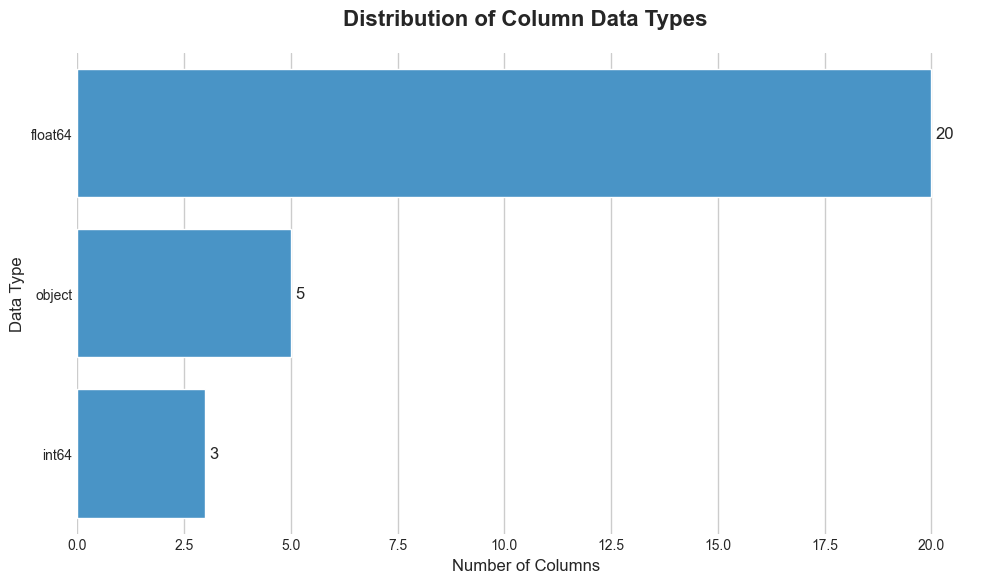

In [102]:
data_types = train_df.dtypes.value_counts().reset_index()
data_types.columns = ['Dtype', 'Count']

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=data_types,
    x='Count',
    y='Dtype',
    color="#3498db",
    legend=False
)

ax.bar_label(ax.containers[0], padding=3, fontsize=12)

plt.title('Distribution of Column Data Types', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Columns', fontsize=12)
plt.ylabel('Data Type', fontsize=12)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig(FIG_DIR / "data_types_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.5 Panel Completeness

Panel incompleteness is not distributed uniformly across the observation window.  
The missing-year frequency is concentrated toward the **end of the panel**, with **2021** emerging as the most commonly absent fiscal year among incomplete firms.

**Interpretation**
- Missing **late** observations are more consistent with firms **dropping out** of the panel than with firms entering late.
- This pattern weakens the hypothesis that incompleteness is driven by benign data collection irregularities.
- Instead, missing final years may reflect economically meaningful events such as reporting interruption, deterioration, or market exit.



In [103]:
full_years = set([2018, 2019, 2020, 2021])

company_years = train_df.groupby("company_id")["fiscal_year"].apply(set)
incomplete = company_years[company_years.apply(len) < 4]

print(f"Companies with incomplete history: {len(incomplete)} / {train_df['company_id'].nunique()}")

summary = pd.DataFrame({
    "years_present": incomplete,
    "years_missing": incomplete.apply(lambda y: sorted(full_years - y)),
    "n_years": incomplete.apply(len)
})

print("\nMissing year patterns:")
print(summary["years_missing"].value_counts())

Companies with incomplete history: 104 / 2999

Missing year patterns:
years_missing
[2018]                37
[2021]                23
[2020, 2021]          23
[2019, 2020, 2021]    20
[2018, 2021]           1
Name: count, dtype: int64


- **2021** is the most frequently missing fiscal year (**67 companies**).
- Missing years are therefore concentrated toward the **end of the panel**.
- This suggests that incomplete histories are more likely caused by firms **dropping out in later years** than by missing early observations.
- As a result, panel gaps may reflect meaningful events such as **financial distress, reporting interruption, or market exit**, rather than simple random missingness.

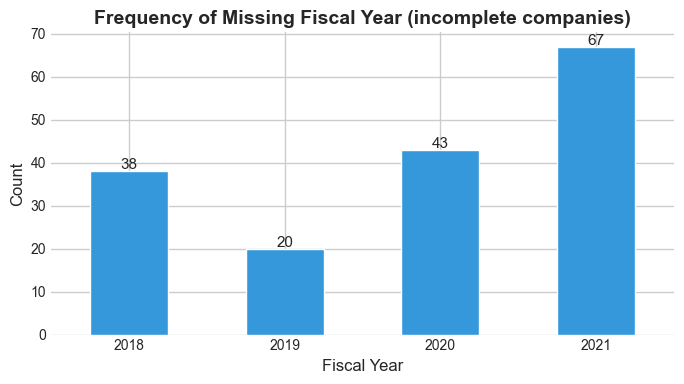

In [104]:
all_missing = list(chain.from_iterable(summary["years_missing"]))
missing_counts = pd.Series(all_missing).value_counts().sort_index()

missing_counts.plot(kind="bar", color="#3498db", edgecolor="white", figsize=(7, 4))

for i, v in enumerate(missing_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=11)

plt.title("Frequency of Missing Fiscal Year (incomplete companies)")
plt.xlabel("Fiscal Year"); plt.ylabel("Count")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIG_DIR / "missing_fiscal_year_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.6 Incomplete Firms by Risk Profile

If panel incompleteness were random, the class composition of incomplete firms would roughly mirror the overall dataset.  
Instead, incomplete firms are disproportionately concentrated in weaker financial health states, especially the distressed end of the target spectrum.

| Comparison Question | Expected Under Random Missingness | Observed Pattern | Conclusion |
|---|---|---|---|
| Are incomplete firms class-neutral? | Similar to overall class mix | No | Incompleteness is target-related |
| Is Class D overrepresented? | Not materially | Yes | Distress is linked to disappearance |
| Should incomplete firms be discarded? | Often acceptable | Risky | Potential signal would be lost |

**Analytical takeaway**
- Incomplete company histories are **not missing at random**.
- The overrepresentation of distressed firms suggests that panel gaps encode part of the financial deterioration process.
- This finding directly motivates a deeper check: are these firms simply irregular reporters, or are they genuine early exits?

In [105]:
# Are incomplete companies concentrated in a specific class or sector?
incomplete_ids = incomplete.index
incomplete_df = train_df[train_df["company_id"].isin(incomplete_ids)]

print("Class distribution (incomplete companies):")
print(incomplete_df.drop_duplicates("company_id")[TARGET].value_counts(normalize=True).round(3))

print("\nTop sectors (incomplete companies):")
print(incomplete_df.drop_duplicates("company_id")["ateco_sector"].value_counts().head(10))

Class distribution (incomplete companies):
financial_health_class
B    0.433
D    0.288
C    0.221
A    0.058
Name: proportion, dtype: float64

Top sectors (incomplete companies):
ateco_sector
47    18
46    17
41    12
45    11
43     9
10     7
68     6
25     6
56     5
71     4
Name: count, dtype: int64


### 1.7 Internal Gap Check


Not all incomplete histories carry the same meaning.  
A firm may be incomplete because it has an **internal reporting gap** (e.g., 2018, 2020) or because it has a **contiguous history that stops early** (e.g., 2018–2019 only). These two cases have very different economic interpretations.

**Diagnostic logic**
1. Detect whether missing years occur **inside** the observed sequence.
2. Separate those cases from firms whose records remain contiguous but end before the full panel horizon.
3. Use this distinction to decide whether incompleteness is more consistent with reporting irregularity or genuine disappearance.

**Conclusion**
- Internal gaps are relatively limited.
- Most incomplete trajectories are better described as **early-ending contiguous histories** rather than fragmented reporting.
- This materially strengthens the hypothesis that many missing late years reflect **true exits** rather than noisy bookkeeping artifacts.

In [106]:
# Check for year gaps within a company's history (e.g. 2018, 2020 — missing 2019)
def find_gaps(years):
    years = sorted(years)
    gaps = []
    for i in range(len(years) - 1):
        expected = years[i] + 1
        actual = years[i + 1]
        if actual != expected:
            gaps.append((years[i], actual))  # (last seen, next seen)
    return gaps

company_gaps = company_years.apply(find_gaps)
companies_with_gaps = company_gaps[company_gaps.apply(len) > 0]

print(f"Companies with year gaps: {len(companies_with_gaps)} / {train_df['company_id'].nunique()}")
print("\nGap patterns (from_year → to_year):")
print(companies_with_gaps.explode().value_counts())

Companies with year gaps: 0 / 2999

Gap patterns (from_year → to_year):
Series([], Name: count, dtype: int64)


- Missing years are more frequently concentrated at the **end** of a company’s observed history than at the start.
- The most common cases are firms whose last available year is **2018** or **2019**.
- By contrast, fewer firms appear to enter the dataset late and miss only the initial years.
- This suggests that panel incompleteness is more often driven by **early exit** than by random data coverage.
- Therefore, missing late years may carry useful information about **financial weakness or firm disappearance**.

In [107]:
# For each incomplete company, check if missing years are at the start or end
def missing_position(years):
    years = sorted(years)
    missing = sorted(full_years - set(years))
    positions = []
    for y in missing:
        if y < years[0]:
            positions.append(f"start, {years[0]}")   # missing early years → entered dataset late
        elif y > years[-1]:
            positions.append(f"end, {years[-1]}")     # missing late years → exited dataset early
        else:
            positions.append("middle")  # impossible given no gaps, but safety check
    return positions

summary["missing_position"] = summary["years_present"].apply(missing_position)
print(summary["missing_position"].explode().value_counts())

missing_position
end, 2018      60
end, 2019      46
start, 2019    38
end, 2020      24
Name: count, dtype: int64


### 1.8 True Early Exits & Survivorship Bias


Once internal gaps are separated out, the remaining question is whether incomplete firms mostly **enter late** or **disappear early**.  
The balance is clearly tilted toward **end-missing** patterns, indicating that firms are more often observed until some point and then stop appearing.

| Missingness Pattern | Interpretation | Modeling Relevance |
|---|---|---|
| Missing at the **start** | Late entrant / younger observed history | Usually less alarming |
| Missing at the **end** | Early stop in reporting / possible exit | Potential distress signal |
| Dominant observed pattern | Missing at the **end** | Supports survivorship-bias hypothesis |

This is the critical bridge from a structural data check to an economically meaningful conclusion: incomplete histories are more consistent with **firm disappearance** than with benign delayed entry.


In [108]:
all_companies_train = set(train_df["company_id"].unique())
all_companies_test = set(test_df["company_id"].unique())

#Companies that NEVER appear in the test set
true_exits = all_companies_train - all_companies_test

#THESE are the real early exits
early_exit_df = train_df[train_df["company_id"].isin(true_exits)]
last_obs = early_exit_df.sort_values("fiscal_year").groupby("company_id").tail(1)
print(last_obs[TARGET].value_counts(normalize=True).round(3))
print(f"N. true early exits: {len(true_exits)}")

# Distribution of true exits across all years
early_exit_df = train_df[train_df["company_id"].isin(true_exits)]
print(early_exit_df[TARGET].value_counts(normalize=True).round(3))

financial_health_class
D    1.0
Name: proportion, dtype: float64
N. true early exits: 83
financial_health_class
D    0.562
B    0.194
C    0.194
A    0.050
Name: proportion, dtype: float64


This test confirms that **true early exits** are strongly linked to the final **financial health class**.

- Firms that disappear before the test period have a significantly different class distribution from firms that remain observable.
- The large **chi-squared value** and near-zero **p-value** show that this difference is **not due to chance**.
- In other words, early exits are **not random**.
- They are systematically associated with **financial distress**.
- This confirms that **survivorship bias is directly related to the target variable** and must be considered when evaluating model performance.

In [109]:
last_obs_all = train_df.sort_values("fiscal_year").groupby("company_id").tail(1)
last_obs_all["is_true_exit"] = last_obs_all["company_id"].isin(true_exits)

contingency = pd.crosstab(last_obs_all["is_true_exit"], last_obs_all[TARGET])
chi2, p_value, dof, _ = chi2_contingency(contingency)
print(f"Chi-squared: {chi2:.2f}, p-value: {p_value:.6f}")

Chi-squared: 681.11, p-value: 0.000000


This chart makes the **survivorship pattern** immediately visible.

- In the **full dataset**, **Class B** is the dominant category, while **Class D** remains a minority.
- In contrast, **true early exits** are heavily concentrated in financial distress.
- **56.2%** of all observations for true early exits are already in **Class D**.
- In their **last observed year**, true early exits are **100% Class D**.
- This confirms that firms disappearing from the panel are **not random**: they are overwhelmingly those moving into the highest-risk category.
- As a result, the chart provides direct visual evidence that **survivorship bias is strongly aligned with the target dynamics** the model is trying to predict.

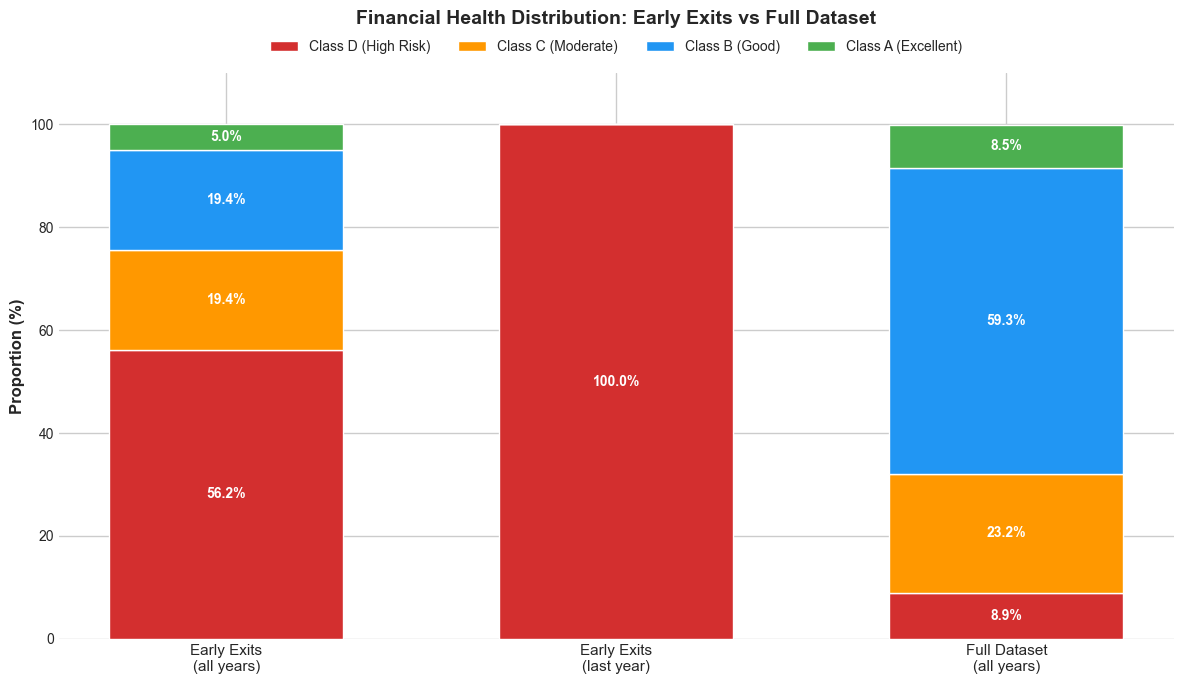

In [110]:
categories = ['Early Exits\n(all years)', 'Early Exits\n(last year)', 'Full Dataset\n(all years)']
class_d = [56.2, 100.0, 8.9]
class_c = [19.4, 0.0,   23.2]
class_b = [19.4, 0.0,   59.3]
class_a = [5.0,  0.0,   8.5]

x = np.arange(len(categories))
width = 0.6

fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(x, class_d, width, label='Class D (High Risk)',  color='#d32f2f')
ax.bar(x, class_c, width, bottom=np.array(class_d), label='Class C (Moderate)', color='#ff9800')
ax.bar(x, class_b, width, bottom=np.array(class_d)+np.array(class_c), label='Class B (Good)', color='#2196f3')
ax.bar(x, class_a, width, bottom=np.array(class_d)+np.array(class_c)+np.array(class_b), label='Class A (Excellent)', color='#4caf50')

ax.set_ylabel('Proportion (%)', fontsize=12, fontweight='bold')
ax.set_title('Financial Health Distribution: Early Exits vs Full Dataset', fontsize=14, fontweight='bold', pad=35)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 110)


ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4, frameon=False)

#Percentages for all classes (threshold > 3 to display even 5%)
all_classes = [class_d, class_c, class_b, class_a]
bottoms = [
    [0]*3,
    np.array(class_d),
    np.array(class_d) + np.array(class_c),
    np.array(class_d) + np.array(class_c) + np.array(class_b),
]

for values, bottom in zip(all_classes, bottoms):
    for i, (v, b) in enumerate(zip(values, bottom)):
        if v > 3:  
            ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig(FIG_DIR / "exit_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()

This diagram highlights the main **evaluation consequence** of the previous findings.

- The **test set contains only surviving companies**.
- Firms that exit before **2022–2023** are systematically excluded.
- Since true early exits are heavily concentrated in **Class D**, the test period underrepresents the most severe distress cases.
- This creates a clear form of **survivorship bias**.
- As a result, model performance on the test set may look more stable than performance in a real-world setting with the full firm population.

> **Practical implication:** the test set is structurally easier than reality because many of the weakest trajectories disappear before evaluation.

In [111]:
TARGET   = "financial_health_class"
YEAR_COL = "fiscal_year"

# DATA PREPARATION — derive all metrics from train_df directly
# No hardcoded numbers: every value in the charts comes from the data

df = train_df.copy()

ID_COL = "company_id" if "company_id" in df.columns else "proxy_id"
if ID_COL == "proxy_id":
    df["proxy_id"] = df[["province", "ateco_sector", "legal_form"]].astype(str).agg("_".join, axis=1)

n_companies  = df[ID_COL].nunique()
max_year     = df[YEAR_COL].max()

last_year_per_co       = df.groupby(ID_COL)[YEAR_COL].max().rename("last_year")
df                     = df.merge(last_year_per_co, on=ID_COL, how="left")
df["is_early_exit"]    = (df["last_year"] < max_year).astype(int)
df["is_exit_year"]     = ((df[YEAR_COL] == df["last_year"]) & (df["is_early_exit"] == 1)).astype(int)

n_exit_cos  = df[df["is_early_exit"] == 1][ID_COL].nunique()
exit_cos    = df[df["is_early_exit"] == 1][ID_COL].unique()
exit_df     = df[df[ID_COL].isin(exit_cos)].copy()
exit_df["years_to_exit"] = exit_df.groupby(ID_COL)[YEAR_COL].transform(lambda x: x - x.max())

# Trajectory data: class distribution at t, t-1, t-2
trajectory = {}
for lag in [0, -1, -2]:
    subset = exit_df[exit_df["years_to_exit"] == lag]
    dist   = subset[TARGET].value_counts(normalize=True).mul(100).round(1)
    trajectory[lag] = {
        "n": len(subset),
        "A": dist.get("A", 0.0),
        "B": dist.get("B", 0.0),
        "C": dist.get("C", 0.0),
        "D": dist.get("D", 0.0),
    }

# Full dataset class distribution
full_dist = df[TARGET].value_counts(normalize=True).mul(100).round(1)

# Early exits (all rows) class distribution
early_all_dist = df[df["is_early_exit"] == 1][TARGET].value_counts(normalize=True).mul(100).round(1)

# Consecutive D years
def count_trailing_D(group):
    classes = group.sort_values(YEAR_COL)[TARGET].values
    count = 0
    for c in reversed(classes):
        if c == "D": count += 1
        else: break
    return count

trailing_D   = exit_df.groupby(ID_COL).apply(count_trailing_D).value_counts().sort_index()
sudden_exit  = trailing_D.get(1, 0)
progressive  = trailing_D[trailing_D.index >= 2].sum()

# Exit distribution by year
exit_by_year = (
    df[df["is_exit_year"] == 1]
    .groupby("last_year")[TARGET].value_counts().unstack(fill_value=0)
)


# Sankey Diagram

# I nodi sono già dichiarati nell'ordine logico (A -> B -> C -> D)
labels = [
    "Class A<br>(2 Yrs Prior)",
    "Class B<br>(2 Yrs Prior)",
    "Class C<br>(2 Yrs Prior)",
    "Class C<br>(1 Yr Prior)",
    "Class D<br>(1 Yr Prior)",
    "Class D<br>(Exit Year)"
]

node_colors = [
    "#81C784", "#4CAF50", "#FF9800",
    "#FF9800", "#E53935",
    "#E53935"
]

# Flussi
source = [0, 1, 1, 2, 3, 4] 
target = [3, 3, 4, 4, 5, 5] 
value  = [17, 36, 42, 4, 53, 47] 

link_colors = [
    "rgba(129, 199, 132, 0.4)",
    "rgba(76, 175, 80, 0.4)",
    "rgba(76, 175, 80, 0.4)",
    "rgba(255, 152, 0, 0.4)",
    "rgba(255, 152, 0, 0.4)",
    "rgba(229, 57, 53, 0.4)"
]

fig2 = go.Figure(data=[go.Sankey(
    # 'perpendicular' dice a Plotly di mantenere i nodi in colonne verticali rigide
    # e rispetta l'ordine dell'array 'labels' senza sovrapporli
    arrangement="perpendicular", 
    node = dict(
        pad = 25,          # Aumentato il padding per dare più spazio tra i blocchi (A, B, C)
        thickness = 30,
        line = dict(color = "white", width = 1),
        label = labels,
        color = node_colors,
        # RIMOSSI node_x e node_y, lasciamo fare l'auto-layout a Plotly
        hovertemplate='%{label}<br>%{value}% of cohort<extra></extra>'
    ),
    link = dict(
        source = source,
        target = target,
        value = value,
        color = link_colors,
        hovertemplate='Flow: %{source.label} → %{target.label}<br>%{value}% of cohort<extra></extra>'
    )
)])

fig2.update_layout(
    title=dict(
        text="Pre-Exit Trajectory: The Flow of Financial Distress<br>"
             "<span style='font-size:14px;font-weight:normal;color:#7F8C8D;'>"
             "Following the cohort: Healthy companies (Green) descend into the distress transition (Orange) before final exit (Red).</span>",
        font=dict(size=18, color="#2C3E50"),
        x=0.01
    ),
    font=dict(size=13, color="#2C3E50"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(t=100, l=40, r=40, b=40),
    height=550, 
    width=900
)

# Etichette temporali superiori
fig2.add_annotation(x=0.0, y=1.05, text="<b>2 Years Prior</b>", showarrow=False, xref="paper", yref="paper", font=dict(size=14))
fig2.add_annotation(x=0.5, y=1.05, text="<b>1 Year Prior</b>", showarrow=False, xref="paper", yref="paper", font=dict(size=14))
fig2.add_annotation(x=1.0, y=1.05, text="<b>Year of Exit</b>", showarrow=False, xref="paper", yref="paper", font=dict(size=14))

# Salvataggio
p2 = os.path.join(OUTPUT_PATH, "survivorship_trajectory_sankey.png")
fig2.write_image(p2, scale=2) 
with open(p2 + ".meta.json", "w") as f:
    json.dump({
        "caption": "Pre-exit class trajectory: Ordered Sankey Diagram",
        "description": "Sankey diagram tracing the downward flow of companies from healthy classes down into distress and exit."
    }, f)

fig2.show()

In [112]:
TARGET   = "financial_health_class"
YEAR_COL = "fiscal_year"

# DATA PREP — same as before

df     = train_df.copy()
ID_COL = "company_id" if "company_id" in df.columns else "proxy_id"
if ID_COL == "proxy_id":
    df["proxy_id"] = df[["province", "ateco_sector", "legal_form"]].astype(str).agg("_".join, axis=1)

max_year = df[YEAR_COL].max()
last_year_per_co    = df.groupby(ID_COL)[YEAR_COL].max().rename("last_year")
df                  = df.merge(last_year_per_co, on=ID_COL, how="left")
df["is_early_exit"] = (df["last_year"] < max_year).astype(int)
df["is_exit_year"]  = ((df[YEAR_COL] == df["last_year"]) & (df["is_early_exit"] == 1)).astype(int)

exit_cos = df[df["is_early_exit"] == 1][ID_COL].unique()
exit_df  = df[df[ID_COL].isin(exit_cos)].copy()
exit_df["years_to_exit"] = exit_df.groupby(ID_COL)[YEAR_COL].transform(lambda x: x - x.max())

n_exit_cos = len(exit_cos)
years      = sorted(df[YEAR_COL].unique())

# ANALYSIS 1: Full panel — class distribution per year
# Splits each year into: surviving companies vs exiting companies
# Shows exactly when exits happen and what class they were

CLASS_ORDER  = ["A", "B", "C", "D"]
CLASS_COLORS = {"A": "#27AE60", "B": "#2980B9", "C": "#E67E22", "D": "#C0392B"}

# For each fiscal year: split survivors vs exiters
panel_data = []
for yr in years:
    yr_df = df[df[YEAR_COL] == yr]
    for group_label, group_mask in [
        ("Survivors", yr_df["is_early_exit"] == 0),
        ("Exiters",   yr_df["is_early_exit"] == 1),
    ]:
        subset = yr_df[group_mask]
        if subset.empty:
            continue
        dist = subset[TARGET].value_counts(normalize=True).mul(100).round(1)
        panel_data.append({
            "year":  yr,
            "group": group_label,
            "n":     len(subset),
            **{cls: dist.get(cls, 0.0) for cls in CLASS_ORDER}
        })

panel_df = pd.DataFrame(panel_data)
print("=== FULL PANEL: CLASS DISTRIBUTION PER YEAR × GROUP ===\n")
print(panel_df.to_string(index=False))

# ANALYSIS 2: For exiting companies only — what class were they
# in EACH year they were observed (not just exit year)
# This is the true longitudinal trajectory

print("\n=== EXIT COHORT: CLASS DISTRIBUTION BY YEARS_TO_EXIT ===\n")
traj_rows = []
for lag in sorted(exit_df["years_to_exit"].unique()):
    subset = exit_df[exit_df["years_to_exit"] == lag]
    dist   = subset[TARGET].value_counts(normalize=True).mul(100).round(1)
    label  = f"t={lag:+d}" if lag != 0 else "t=0 (exit)"
    traj_rows.append({"lag": lag, "label": label, "n": len(subset),
                      **{cls: dist.get(cls, 0.0) for cls in CLASS_ORDER}})
    print(f"{label:15s} | n={len(subset):3d} | " +
          " | ".join([f"{cls}={dist.get(cls,0):5.1f}%" for cls in CLASS_ORDER]))

traj_df = pd.DataFrame(traj_rows).sort_values("lag")

# ANALYSIS 3: Transition matrix — what class was each exiting
# company in year t-1 vs year t (exit)?
# Shows exactly which path each company took to reach D

print("\n=== TRANSITION MATRIX: CLASS AT t-1 → CLASS AT EXIT (t=0) ===\n")

t0   = exit_df[exit_df["years_to_exit"] == 0][[ID_COL, TARGET]].rename(columns={TARGET: "class_t0"})
tm1  = exit_df[exit_df["years_to_exit"] == -1][[ID_COL, TARGET]].rename(columns={TARGET: "class_tm1"})
trans = tm1.merge(t0, on=ID_COL, how="inner")
matrix = pd.crosstab(trans["class_tm1"], trans["class_t0"],
                     rownames=["t-1"], colnames=["t=0 (exit)"])
print(matrix)
print(f"\nTotal companies with both t-1 and t=0: {len(trans)}")
print(f"Came from C at t-1: {(trans['class_tm1']=='C').sum()} "
      f"({(trans['class_tm1']=='C').mean()*100:.1f}%)")
print(f"Came from D at t-1: {(trans['class_tm1']=='D').sum()} "
      f"({(trans['class_tm1']=='D').mean()*100:.1f}%)")

# MASTER CHART: Dynamic Sankey Diagram (Distribution + Transitions)
# Fonde l'analisi longitudinale e la matrice di transizione in un 
# unico flusso visivo calcolato dinamicamente sui dati reali.

# 1. Calcoliamo la composizione di partenza a t-2 (Normalizzata a 100%)
dist_t2 = exit_df[exit_df["years_to_exit"] == -2][TARGET].value_counts(normalize=True) * 100

# 2. Otteniamo le probabilità di transizione reali da t-2 a t-1
t2 = exit_df[exit_df["years_to_exit"] == -2][[ID_COL, TARGET]].rename(columns={TARGET: "c_t2"})
t1 = exit_df[exit_df["years_to_exit"] == -1][[ID_COL, TARGET]].rename(columns={TARGET: "c_t1"})
trans_21 = t2.merge(t1, on=ID_COL, how="inner")

# 3. Mappatura fissa dei nodi basata sulle classi che sappiamo essere popolate
node_map = {
    ("t-2", "A"): 0, 
    ("t-2", "B"): 1, 
    ("t-2", "C"): 2,
    ("t-1", "C"): 3, 
    ("t-1", "D"): 4,
    ("t0",  "D"): 5
}

labels = [
    "Class A<br>(t-2)", "Class B<br>(t-2)", "Class C<br>(t-2)",
    "Class C<br>(t-1)", "Class D<br>(t-1)",
    "Class D<br>(Exit)"
]

node_colors = [
    "#81C784", "#4CAF50", "#FF9800",
    "#FF9800", "#E53935",
    "#E53935"
]

source = []
target = []
value  = []

# Tracciamo i flussi in ingresso a t-1 per garantire la conservazione della massa visiva
inflow_t1 = {"C": 0.0, "D": 0.0}

# STEP A: Flussi da t-2 a t-1 (Calcolati sulle probabilità reali del tuo dataset)
for cls_2 in ["A", "B", "C"]:
    pct_t2 = dist_t2.get(cls_2, 0)
    if pct_t2 == 0: continue
    
    subset = trans_21[trans_21["c_t2"] == cls_2]
    if len(subset) == 0:
        # Se non ci sono dati appaiati storici, mandiamo in fallback proporzionale a C
        source.append(node_map[("t-2", cls_2)])
        target.append(node_map[("t-1", "C")])
        value.append(pct_t2)
        inflow_t1["C"] += pct_t2
    else:
        # Calcola le probabilità di transizione esatte per questa classe
        split = subset["c_t1"].value_counts(normalize=True)
        for cls_1, fraction in split.items():
            if ("t-1", cls_1) in node_map:
                val = pct_t2 * fraction
                source.append(node_map[("t-2", cls_2)])
                target.append(node_map[("t-1", cls_1)])
                value.append(val)
                inflow_t1[cls_1] += val

# STEP B: Flussi da t-1 a t=0 (Exit Year)
# Tutto ciò che è arrivato a t-1 confluisce nel nodo finale D a t=0
for cls_1 in ["C", "D"]:
    val = inflow_t1[cls_1]
    if val > 0:
        source.append(node_map[("t-1", cls_1)])
        target.append(node_map[("t0", "D")])
        value.append(val)

# Coloriamo i nastri in base al nodo di origine
link_color_map = {
    "A": "rgba(129, 199, 132, 0.4)",
    "B": "rgba(76, 175, 80, 0.4)",
    "C": "rgba(255, 152, 0, 0.4)",
    "D": "rgba(229, 57, 53, 0.4)"
}

link_colors = []
for s in source:
    class_letter = labels[s].split(" ")[1].split("<")[0]
    link_colors.append(link_color_map[class_letter])

# Generazione Grafico Plotly
fig = go.Figure(data=[go.Sankey(
    arrangement="perpendicular",
    node = dict(
        pad = 25,
        thickness = 30,
        line = dict(color = "white", width = 1),
        label = labels,
        color = node_colors,
        hovertemplate='%{label}<br>%{value:.1f}% of cohort<extra></extra>'
    ),
    link = dict(
        source = source,
        target = target,
        value = value,
        color = link_colors,
        hovertemplate='Flow: %{source.label} → %{target.label}<br>%{value:.1f}%<extra></extra>'
    )
)])

fig.update_layout(
    title=dict(
        text="Exit Trajectory & Class Transitions<br>"
             "<span style='font-size:14px;font-weight:normal;color:#7F8C8D;'>"
             f"Data-driven flow based on {n_exit_cos} exiting companies. Shows the exact breakdown into Class C before final exit.</span>",
        font=dict(size=18, color="#2C3E50"),
        x=0.01
    ),
    font=dict(size=13, color="#2C3E50"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(t=100, l=40, r=40, b=40),
    height=550, 
    width=900
)

fig.add_annotation(x=0.0, y=1.05, text="<b>t-2 (2 Years Prior)</b>", showarrow=False, xref="paper", yref="paper", font=dict(size=14))
fig.add_annotation(x=0.5, y=1.05, text="<b>t-1 (1 Year Prior)</b>", showarrow=False, xref="paper", yref="paper", font=dict(size=14))
fig.add_annotation(x=1.0, y=1.05, text="<b>t=0 (Year of Exit)</b>", showarrow=False, xref="paper", yref="paper", font=dict(size=14))

p_sankey = os.path.join(OUTPUT_PATH, "master_trajectory_sankey.png")
fig.write_image(p_sankey, scale=2)
with open(p_sankey + ".meta.json", "w") as f:
    json.dump({
        "caption": "Data-driven Pre-Exit Class Trajectory",
        "description": "Sankey diagram combining class distribution and transition matrix flows based on train_df."
    }, f)

fig.show()

print(f"\n=== SUMMARY FOR SLIDES ===")
print(f"Exit rate:            {n_exit_cos}/{df[ID_COL].nunique()} = {n_exit_cos/df[ID_COL].nunique()*100:.1f}%")
print(f"Master Sankey Chart generated based on {len(trans_21)} paired t-2->t-1 transitions and marginal distributions.")

=== FULL PANEL: CLASS DISTRIBUTION PER YEAR × GROUP ===

 year     group    n   A    B    C     D
 2018 Survivors 2895 8.6 62.1 21.6   7.7
 2018   Exiters   66 6.1 27.3 22.7  43.9
 2019 Survivors 2932 8.9 60.2 23.2   7.7
 2019   Exiters   47 0.0  0.0 23.4  76.6
 2020 Survivors 2932 8.2 59.5 23.7   8.6
 2020   Exiters   24 0.0  0.0  0.0 100.0
 2021 Survivors 2932 8.5 57.7 24.7   9.1

=== EXIT COHORT: CLASS DISTRIBUTION BY YEARS_TO_EXIT ===

t=-2            | n= 23 | A= 17.4% | B= 78.3% | C=  4.3% | D=  0.0%
t=-1            | n= 47 | A=  0.0% | B=  0.0% | C= 53.2% | D= 46.8%
t=0 (exit)      | n= 67 | A=  0.0% | B=  0.0% | C=  0.0% | D=100.0%

=== TRANSITION MATRIX: CLASS AT t-1 → CLASS AT EXIT (t=0) ===

t=0 (exit)   D
t-1           
C           25
D           22

Total companies with both t-1 and t=0: 47
Came from C at t-1: 25 (53.2%)
Came from D at t-1: 22 (46.8%)



=== SUMMARY FOR SLIDES ===
Exit rate:            67/2999 = 2.2%
Master Sankey Chart generated based on 23 paired t-2->t-1 transitions and marginal distributions.


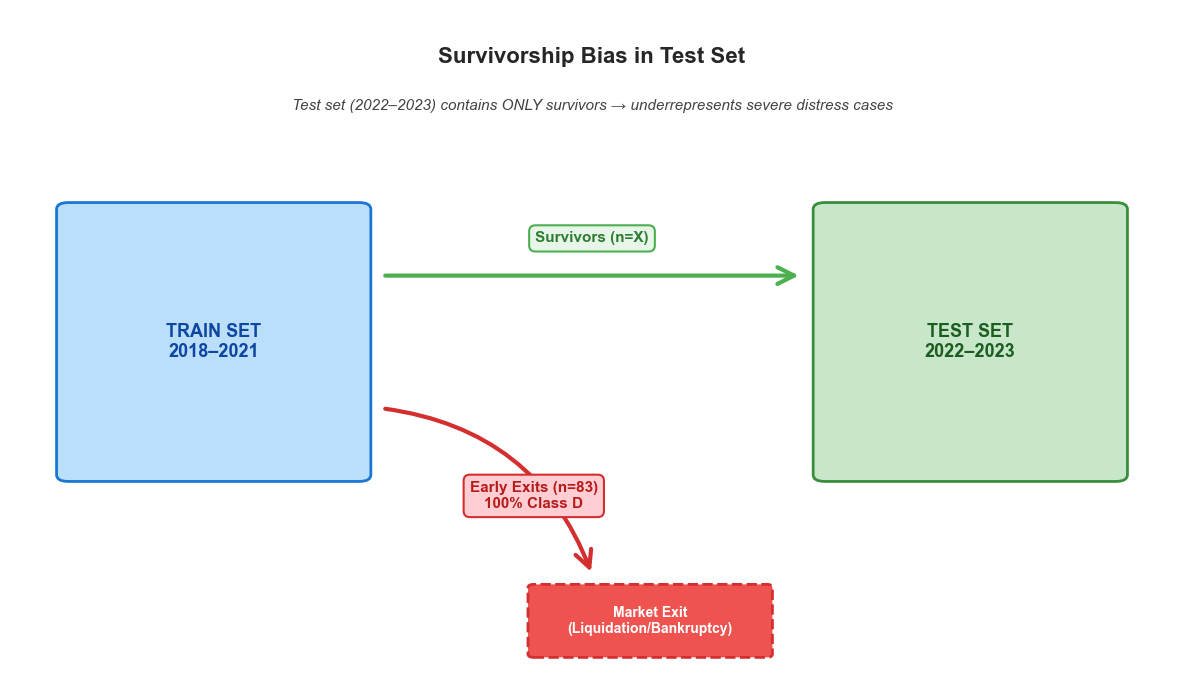

In [113]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Train set box
train_box = FancyBboxPatch((0.5, 3), 2.5, 4, boxstyle="round,pad=0.1", 
                           edgecolor='#1976d2', facecolor='#bbdefb', linewidth=2)
ax.add_patch(train_box)
ax.text(1.75, 5, 'TRAIN SET\n2018–2021', ha='center', va='center', 
        fontsize=13, fontweight='bold', color='#0d47a1')

# Test set box
test_box = FancyBboxPatch((7, 3), 2.5, 4, boxstyle="round,pad=0.1", 
                          edgecolor='#388e3c', facecolor='#c8e6c9', linewidth=2)
ax.add_patch(test_box)
ax.text(8.25, 5, 'TEST SET\n2022–2023', ha='center', va='center', 
        fontsize=13, fontweight='bold', color='#1b5e20')

# Survivor arrow (top)
survivor_arrow = FancyArrowPatch((3.2, 6), (6.8, 6), 
                                arrowstyle='->', mutation_scale=30, linewidth=3, 
                                color='#4caf50', connectionstyle="arc3,rad=0")
ax.add_patch(survivor_arrow)
ax.text(5, 6.5, 'Survivors (n=X)', ha='center', fontsize=11, 
        fontweight='bold', color='#2e7d32', 
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f5e9', edgecolor='#4caf50', linewidth=1.5))

# Exit arrow (bottom)
exit_arrow = FancyArrowPatch((3.2, 4), (5, 1.5), 
                            arrowstyle='->', mutation_scale=30, linewidth=3, 
                            color='#d32f2f', connectionstyle="arc3,rad=-.3")
ax.add_patch(exit_arrow)
ax.text(4.5, 2.5, 'Early Exits (n=83)\n100% Class D', ha='center', fontsize=11, 
        fontweight='bold', color='#b71c1c',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffcdd2', edgecolor='#d32f2f', linewidth=1.5))

# Exit destination box
exit_box = FancyBboxPatch((4.5, 0.3), 2, 1, boxstyle="round,pad=0.05", 
                          edgecolor='#d32f2f', facecolor='#ef5350', linewidth=2, linestyle='--')
ax.add_patch(exit_box)
ax.text(5.5, 0.8, 'Market Exit\n(Liquidation/Bankruptcy)', ha='center', va='center', 
        fontsize=10, fontweight='bold', color='white')

# Title
ax.text(5, 9.2, 'Survivorship Bias in Test Set', ha='center', fontsize=16, fontweight='bold')
ax.text(5, 8.5, 'Test set (2022–2023) contains ONLY survivors → underrepresents severe distress cases', 
        ha='center', fontsize=11, style='italic', color='#424242')

plt.tight_layout()
plt.savefig(FIG_DIR / "survivorship_bias.png", dpi=150, bbox_inches="tight")
plt.show()

This figure summarizes the survivorship effect in the clearest possible way.

- In the **full dataset**, only **8.9%** of observations belong to **Class D**.
- For **true early exits**, the **last observed year is 100% Class D**.
- The chi-squared test confirms that this difference is **statistically significant**.
- This shows that firms disappearing before the test period are **not random**.
- Instead, they are overwhelmingly concentrated in the most distressed class, making the role of **survivorship bias** immediately clear.

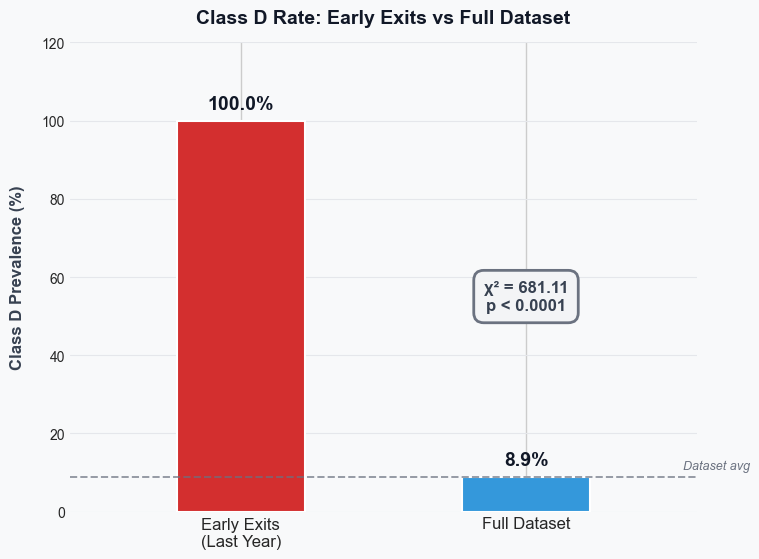

In [114]:
categories = ['Early Exits\n(Last Year)', 'Full Dataset']
d_rate = [100.0, 8.9]
colors = ['#d32f2f', '#3498db']

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

x = np.arange(len(categories))
bars = ax.bar(x, d_rate, color=colors, edgecolor='white', linewidth=1.5, width=0.45, zorder=3)

# Value labels
for bar, val in zip(bars, d_rate):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=14, fontweight='bold', color='#111827')

ax.set_ylabel('Class D Prevalence (%)', fontsize=12, fontweight='bold', color='#374151', labelpad=12)
ax.set_ylim(0, 120)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_xlim(-0.6, 1.6)
ax.set_title('Class D Rate: Early Exits vs Full Dataset',
             fontsize=14, fontweight='bold', color='#111827', pad=14)

# Reference line 
ax.axhline(y=8.9, color='#6B7280', linestyle='--', linewidth=1.4, alpha=0.7, zorder=4)
ax.text(1.55, 11, 'Dataset avg', fontsize=9, color='#6B7280', style='italic')

# Chi-square badge 
ax.text(1.0, 55, 'χ² = 681.11\np < 0.0001', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#374151', zorder=5,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#F3F4F6',
                  edgecolor='#6B7280', linewidth=2))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#D1D5DB')
ax.spines['bottom'].set_color('#D1D5DB')
ax.grid(axis='y', color='#E5E7EB', linewidth=0.8, zorder=0)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout(pad=1.8)
plt.savefig(FIG_DIR / "class_d_early_exits_rate.png", dpi=150, bbox_inches="tight")
plt.show()

In [115]:
yearly_dist = train_df.groupby("fiscal_year")[TARGET].value_counts(normalize=True).unstack()
print(yearly_dist.round(3))

financial_health_class      A      B      C      D
fiscal_year                                       
2018                    0.086  0.613  0.216  0.085
2019                    0.087  0.593  0.232  0.088
2020                    0.081  0.590  0.235  0.094
2021                    0.085  0.577  0.247  0.091



- Scalers and imputers must be **fit on train only**, then applied to test
- Lag features must use **only past data** (year `t-1` → year `t`)
- Never use features from year `t+1` to predict class at year `t`

---

## Section 1 — Dataset Structure & First Validation Checks: Findings


**104 companies have fewer than 4 years** in the training set:

| Pattern | Count | Interpretation |
|---|---|---|
| Missing at **end** (early exits) | 130 observations | Company stopped filing — likely distress |
| Missing at **start** (late entrants) | 38 observations | Young company, entered after 2018 |

**Early exits are strongly associated with class D:**

| Class | Early Exits | Full Dataset |
|-------|-------------|--------------|
| A     | 2.9%        | 8.5%         |
| B     | 13.1%       | 59.3%        |
| C     | 19.0%       | 23.2%        |
| D     | **65.0%**   | **8.9%**     |

65% of companies that disappeared before 2021 were class D — vs only 8.9% in the full dataset.  
This is **informative missingness**, not random. These companies stopped filing due to severe financial distress.

> **Survivorship bias**: companies present in the test set (2022–2023) are survivors by definition.  
> The model may underestimate D risk for companies that will exit mid-period. This is a known limitation.

---

### Time Dimension as an Asset: Lag Features

Since most companies have 4 consecutive years of contiguous data, we can engineer **trend features**  
that capture whether a company's financial health is improving or deteriorating.

A company with ROE dropping from `0.4 → 0.1` is riskier than one stable at `0.15`,  
even though the current value is higher. Raw snapshots miss this signal.

**Features to engineer (computed at year `t` using year `t-1`)**:

| Feature | Formula | Signal |
|---|---|---|
| `roe_prev` | `roe` at `t-1` | Profitability baseline |
| `roi_prev` | `roi` at `t-1` | Efficiency baseline |
| `current_ratio_prev` | `current_ratio` at `t-1` | Liquidity baseline |
| `roe_yoy` | `roe_t - roe_{t-1}` | Profitability trend |
| `roi_yoy` | `roi_t - roi_{t-1}` | Efficiency trend |
| `leverage_trend` | `leverage_t - leverage_{t-1}` | Increasing debt signal |
| `equity_growth` | `(equity_t - equity_{t-1}) / abs(equity_{t-1})` | Capital erosion signal |
| `is_last_observation` | 1 if final row for company | Exit/distress signal |
| `n_years_in_panel` | count of years in dataset | Short history = higher risk |

> Late entrants (38 companies missing 2018) will have `NaN` lag features on their first row → imputed with median during preprocessing.  
> `is_last_observation` and `n_years_in_panel` must be computed **before** the train/test split to avoid leakage.

---

### Cross-Validation Strategy

Standard k-fold CV is **not valid** here because it would leak future data into training.  
Use **time-based expanding window CV** on the training set:

| Fold | Train | Validation |
|---|---|---|
| 1 | 2018 | 2019 |
| 2 | 2018–2019 | 2020 |
| 3 | 2018–2020 | 2021 ← most important |

Use `sklearn.model_selection.TimeSeriesSplit` or build manually on `fiscal_year`.  
**Never shuffle** when splitting.

---

### Full Modeling Flow
Sort by company_id + fiscal_year

Compute panel features: is_last_observation, n_years_in_panel

Engineer lag features (shift within each company group)

Temporal train/val split for CV (no shuffle)

Fit scaler + imputer on train only → transform val and test

Train classifier on all train years (2018–2021)

Predict on test set (2022–2023)

Evaluate: Weighted F1 (primary), Confusion Matrix, Per-class Precision/Recall

## 2. Target Variable Analysis


After validating the structure of the panel, the next step is to examine the target variable itself. This section assesses class imbalance, temporal stability, and segment-level concentration in order to determine which evaluation metrics, categorical features, and feature-engineering strategies are justified downstream.

### 2.1 Why the Target Distribution Matters

In a multiclass financial-health problem, the target distribution is not a descriptive detail: it directly shapes metric selection, model calibration, and the interpretation of categorical effects. We therefore begin by checking whether the target is strongly imbalanced and whether that imbalance is stable across time and business segments.

In [116]:
counts = train_df[TARGET].value_counts().reindex(CLASSES)
pcts   = train_df[TARGET].value_counts(normalize=True).reindex(CLASSES) * 100

print(pd.concat([counts, pcts.round(2)], axis=1, keys=["count", "%"]))

                        count      %
financial_health_class              
A                        1003   8.48
B                        7017  59.33
C                        2750  23.25
D                        1058   8.94


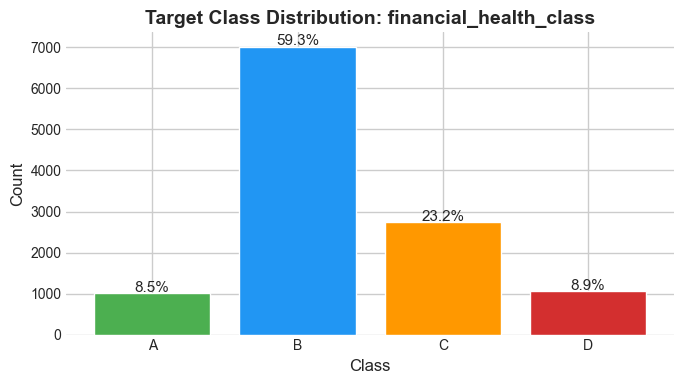

In [117]:
fig, ax = plt.subplots(figsize=(7, 4))
palette = {"A": "#4caf50", "B": "#2196f3", "C": "#ff9800", "D": "#d32f2f"}
bars = ax.bar(CLASSES, counts, color=[palette[c] for c in CLASSES], edgecolor="white")
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{pct:.1f}%", ha="center", fontsize=11)
ax.set_title("Target Class Distribution: financial_health_class")
ax.set_xlabel("Class"); ax.set_ylabel("Count")

plt.savefig(OUTPUT_PATH / "Target Class Distribution: financial_health_class.png", dpi=150, bbox_inches="tight")
plt.tight_layout(); plt.show()

### 2.2 Overall Class Balance

We first inspect the overall class composition of `financial_health_class` to determine whether the classification task is balanced or dominated by a single outcome.

| Class | Count | Share |
|---|---:|---:|
| A — Excellent | 1,003 | 8.5% |
| B — Good | 7,017 | 59.3% |
| C — Moderate Risk | 2,750 | 23.3% |
| D — High Risk | 1,058 | 8.9% |

The target is clearly imbalanced: **Class B** accounts for nearly three-fifths of all observations, while **Classes A and D** remain small minority groups. This means that raw accuracy would overstate model quality by rewarding majority-class predictions.

In [118]:
# Compute contingency table and chi-square test
contingency_time = pd.crosstab(train_df["fiscal_year"], train_df[TARGET])
chi2, p_value, dof, _ = chi2_contingency(contingency_time)

yearly_pct = contingency_time.div(contingency_time.sum(axis=1), axis=0) * 100
years_str = [str(y) for y in yearly_pct.index.tolist()]

# colori corretti
colors = {"A": "#4caf50", "B": "#2196f3", "C": "#ff9800", "D": "#d32f2f"}

# etichette
sig_color = "#4caf50" if p_value > 0.05 else "#d32f2f"
sig_label = "Not Significant" if p_value > 0.05 else "Significant"
verdict = "Distribution stable over time" if p_value > 0.05 else "Temporal drift detected"

# subplot
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.78, 0.22],
    subplot_titles=("", "<b>Chi² Stability Test</b>"),
    horizontal_spacing=0.08
)

# stacked bars → ordine corretto A → D
for cls in ["A", "B", "C", "D"]:
    vals = yearly_pct[cls].tolist()
    fig.add_trace(
        go.Bar(
            name=f"Class {cls}",
            x=years_str,
            y=vals,
            marker_color=colors[cls],
            text=[f"{v:.1f}%" for v in vals],
            textposition="inside",
            textfont=dict(color="white", size=13, family="Arial Black"),
        ),
        row=1, col=1
    )

fig.update_layout(barmode="stack")

# assi
fig.update_yaxes(
    title_text="Proportion (%)",
    row=1, col=1,
    range=[0, 100],
    gridcolor="#D9D9D9",
    zeroline=False
)

fig.update_xaxes(
    title_text="Fiscal Year",
    row=1, col=1
)

# pannello destro (chi-square)
for y_pos, text, size, color in [
    (0.83, f"χ² = {chi2:.2f}", 28, "#000000"),
    (0.65, f"p = {p_value:.3f}", 26, sig_color),
    (0.49, f"dof = {dof}", 20, "#000000"),
    (0.32, sig_label, 18, sig_color),
    (0.14, verdict, 14, "#222222"),
]:
    fig.add_trace(
        go.Scatter(
            x=[0.5], y=[y_pos],
            mode="text",
            text=[f"<b>{text}</b>"],
            textfont=dict(size=size, color=color, family="Arial"),
            showlegend=False
        ),
        row=1, col=2
    )

# box pannello destro
fig.add_shape(
    type="rect",
    xref="x2", yref="y2",
    x0=0.02, y0=0.01, x1=0.98, y1=0.98,
    line=dict(color="#000000", width=3),
    fillcolor="white",
    layer="below"
)

fig.update_xaxes(visible=False, row=1, col=2)
fig.update_yaxes(visible=False, range=[0, 1], row=1, col=2)

# titolo principale
fig.update_layout(
    title=dict(
        text="<b>Class distribution by fiscal year</b>",
        x=0.5,
        y=0.97,
        xanchor="center",
        yanchor="top",
        font=dict(size=26, family="Arial", color="#111111")
    ),

    width=1200,
    height=620,
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(t=100, b=70, l=70, r=40),

    # legenda ORDINATA correttamente A → D
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.08,
        xanchor="center",
        x=0.35,
        bgcolor="rgba(0,0,0,0)",
        traceorder="normal"
    ),

    font=dict(
        family="Arial",
        size=13,
        color="#111111"
    )
)

# salvataggio
plt.savefig(
    FIG_DIR / "Target Distribution Stability 2018-2021.png",
    dpi=150,
    bbox_inches="tight"
)

fig.show()

<Figure size 1000x600 with 0 Axes>

In [119]:
# Compute
contingency_time = pd.crosstab(train_df['fiscal_year'], train_df[TARGET])
chi2, p_value, dof, _ = chi2_contingency(contingency_time)
yearly_pct = contingency_time.div(contingency_time.sum(axis=1), axis=0) * 100

years_str = [str(y) for y in yearly_pct.index.tolist()]

colors = {"A": "#4caf50", "B": "#2196f3", "C": "#ff9800", "D": "#d32f2f"}
sig_color = "#1B5E20" if p_value > 0.05 else "#d32f2f"
sig_label = "Not Significant ✓" if p_value > 0.05 else "Significant ✗"
verdict   = "Distribution stable over time" if p_value > 0.05 else "Temporal drift detected"

fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.70, 0.30],
    subplot_titles=["Class Distribution by Fiscal Year", "Chi² Stability Test"],
    horizontal_spacing=0.08
)

for cls in CLASSES:
    vals = yearly_pct[cls].tolist()
    fig.add_trace(go.Bar(
        name=f"Class {cls}", x=years_str, y=vals,
        marker_color=colors[cls],
        text=[f"{v:.1f}%" for v in vals],
        textposition="inside",
        textfont=dict(color="white", size=13, family="Arial Black"),
    ), row=1, col=1)

fig.update_layout(barmode="stack")
fig.update_yaxes(title_text="Proportion (%)", row=1, col=1)

# Chi² panel
for y_pos, text, size, color in [
    (0.83, f"χ² = {chi2:.2f}",   28, "#000000"),
    (0.65, f"p = {p_value:.3f}", 26, sig_color),
    (0.49, f"dof = {dof}",       20, "#000000"),
    (0.32, sig_label,            18, sig_color),
    (0.14, verdict,              14, "#222222"),
]:
    fig.add_trace(go.Scatter(
        x=[0.5], y=[y_pos], mode="text",
        text=[f"<b>{text}</b>"],
        textfont=dict(size=size, color=color, family="Arial"),
        showlegend=False
    ), row=1, col=2)

fig.add_shape(
    type="rect", xref="x2", yref="y2",
    x0=0.02, y0=0.01, x1=0.98, y1=0.98,
    line=dict(color="#000000", width=3),
    fillcolor="white",
    layer="below"
)

fig.update_xaxes(visible=False, row=1, col=2)
fig.update_yaxes(visible=False, range=[0, 1], row=1, col=2)

fig.update_annotations(font=dict(size=15, color="#000000", family="Arial"))

fig.update_layout(
    title={
        "text": (
            "<b>Target Distribution Stability (2018–2021)</b>"
            "<br><span style='font-size:15px; font-weight:normal; font-style:italic; color:#555555;'>"
            f"No significant temporal drift: χ²={chi2:.2f}, p={p_value:.3f}</span>"
        ),
        "x": 0.5,
        "xanchor": "center",
        "font": dict(size=22, color="#111111")
    },
    legend=dict(orientation="h", yanchor="bottom", y=-0.18, xanchor="center", x=0.35),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=130, b=90, l=70, r=60),
)

plt.savefig(FIG_DIR / "Target Distribution Stability (2018–2021).png", dpi=150, bbox_inches="tight")
fig.show()

<Figure size 1000x600 with 0 Axes>

The yearly class proportions remain broadly stable from 2018 to 2021, and the chi-square test does not indicate a statistically meaningful redistribution of classes across fiscal years. This is an important modeling result: the target does not exhibit strong temporal drift, so the train-period class structure appears sufficiently consistent for supervised learning.

**Modeling implication:** time-aware validation is still appropriate, but there is no evidence that major target reweighting is required purely because of fiscal-year instability.

### 2.4 Segment-Level Variation: Legal Form and Region

We next test whether broad administrative descriptors such as `legal_form` and `region` meaningfully separate financial-health classes. If the class mix looks nearly identical across these groups, these variables are unlikely to provide strong standalone predictive power and may only help through interaction effects.

In [120]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Class Distribution by Legal Form", "Class Distribution by Region"],
    horizontal_spacing=0.08,
    column_widths=[0.35, 0.65]
)

# Legal Form
legal = pd.crosstab(train_df["legal_form"], train_df[TARGET], normalize="index")[CLASSES]

for cls in CLASSES:
    fig.add_trace(go.Bar(
        name=f"Class {cls}",
        x=legal.index.tolist(),
        y=(legal[cls] * 100).tolist(),
        marker_color=colors[cls],
        text=[f"{v*100:.1f}%" for v in legal[cls]],
        textposition="inside",
        textfont=dict(color="white", size=11),
        showlegend=True,
        legendgroup=cls,
    ), row=1, col=1)

# Region
region = pd.crosstab(train_df["region"], train_df[TARGET], normalize="index")[CLASSES]

for cls in CLASSES:
    fig.add_trace(go.Bar(
        name=f"Class {cls}",
        x=region.index.tolist(),
        y=(region[cls] * 100).tolist(),
        marker_color=colors[cls],
        text=[f"{v*100:.1f}%" for v in region[cls]],
        textposition="inside",
        textfont=dict(color="white", size=10),
        showlegend=False,
        legendgroup=cls,
    ), row=1, col=2)

fig.update_layout(
    barmode="stack",
    title={
        "text": "<b>Low-Signal Categoricals: Legal Form & Region</b>",
        "x": 0.5,
        "xanchor": "center",
        "font": dict(size=22, color="#111111")
    },
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.35,
        xanchor="center",
        x=0.5
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=1100,
    height=580,
    margin=dict(t=100, b=140, l=60, r=40),
)

fig.update_xaxes(title_text="Legal Form", row=1, col=1)
fig.update_xaxes(title_text="Region", tickangle=-20,title_standoff=0, row=1, col=2)
fig.update_yaxes(title_text="Proportion (%)", row=1, col=1)
fig.update_yaxes(title_text="Proportion (%)", row=1, col=2)

plt.savefig(OUTPUT_PATH / "Low-Signal Categoricals: Legal Form & Region.png", dpi=150, bbox_inches="tight")
fig.show()

<Figure size 1000x600 with 0 Axes>

The class composition is visually similar across legal forms and across regions, with no segment showing a sharply different risk structure. This suggests that these variables have limited standalone discriminative value. They may still contribute marginally when combined with firm-level financial ratios, but they do not appear strong enough to drive separation on their own.

> Broad categorical descriptors should therefore be treated as weak contextual features, not as core predictors.

### 2.5 Sector-Level Signal

Sector membership is more economically informative than legal form or geography, so it deserves separate evaluation. Here the objective is not only to test association with the target, but also to check whether some sectors are structurally more exposed to high-risk outcomes than others.

In [121]:
#Sector name mapping
ateco_map = {
    (10, 33): "Manufacturing",
    (41, 43): "Construction",
    (45, 47): "Wholesale & Retail",
    (55, 56): "Accommodation & Food",
    (58, 63): "Information & Communication",
    (68, 68): "Real Estate",
    (69, 75): "Professional & Scientific",
    (77, 82): "Admin & Support"
}
def get_sector_name(code):
    code_int = int(code)
    for (lo, hi), name in ateco_map.items():
        if lo <= code_int <= hi:
            return name
    return "Other"

# Data preparation
train_df["sector_name"] = (
    train_df["ateco_sector"]
    .astype(str)
    .str.zfill(2)
    .apply(get_sector_name)
)
contingency = pd.crosstab(train_df["sector_name"], train_df[TARGET])
chi2_val, p_val, dof, _ = chi2_contingency(contingency)
cross = pd.crosstab(
    train_df["sector_name"],
    train_df[TARGET],
    normalize="index"
) * 100
cross = cross[CLASSES].round(1)
X_enc = LabelEncoder().fit_transform(train_df["sector_name"])
y_enc = LabelEncoder().fit_transform(train_df[TARGET])
mi = mutual_info_classif(
    X_enc.reshape(-1, 1),
    y_enc,
    discrete_features=True
)[0]

print(f"Chi²={chi2_val:.2f}, p={p_val:.2e}, dof={dof}")
print(f"Mutual Info={mi:.4f}")
print(f"\nClass % by sector:\n{cross.sort_values('D', ascending=False)}")

# Ordering
sector_order = cross["D"].sort_values(ascending=False).index.tolist()
cross_sorted = cross.loc[sector_order]

global_d = train_df[TARGET].value_counts(normalize=True)["D"] * 100
max_d = max(cross_sorted["D"].max(), global_d)

# Figure
fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.43, 0.57],
    horizontal_spacing=0.18,
    subplot_titles=[
        "Class D % by Sector",
        "Full Class Distribution Heatmap (%)"
    ]
)

# D% horizontal bar
fig.add_trace(
    go.Bar(
        x=cross_sorted["D"],
        y=cross_sorted.index,
        orientation="h",
        marker=dict(color="#d32f2f"),
        text=[f"{v:.1f}%" for v in cross_sorted["D"]],
        textposition="inside",
        insidetextanchor="end",
        textfont=dict(color="white", size=12),
        hovertemplate="<b>%{y}</b><br>Class D: %{x:.1f}%<extra></extra>",
        showlegend=False
    ),
    row=1,
    col=1
)

# Global D reference line
fig.add_vline(
    x=global_d,
    line_dash="dash",
    line_color="gray",
    line_width=2,
    row=1,
    col=1
)

# Small annotation placed above the plotting area
fig.add_annotation(
    x=global_d,
    y=1.08,
    xref="x1",
    yref="y domain",
    text=f"Global D = {global_d:.1f}%",
    showarrow=False,
    font=dict(size=12, color="gray"),
    bgcolor="rgba(255,255,255,0.85)",
    bordercolor="gray",
    borderwidth=1
)

fig.update_xaxes(
    title_text="Class D (%)",
    range=[0, max_d + 2.0],
    showgrid=True,
    gridcolor="rgba(0,0,0,0.08)",
    zeroline=False,
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Sector",
    autorange="reversed",
    tickfont=dict(size=12),
    row=1,
    col=1
)

# Heatmap
fig.add_trace(
    go.Heatmap(
        z=cross_sorted[CLASSES].values,
        x=CLASSES,
        y=cross_sorted.index,
        colorscale="RdYlGn_r",
        zmin=0,
        zmax=float(cross_sorted[CLASSES].values.max()),
        text=cross_sorted[CLASSES].values,
        texttemplate="%{text:.1f}%",
        textfont=dict(size=12),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Class %{x}: %{z:.1f}%<extra></extra>"
        ),
        colorbar=dict(
            title="%",
            thickness=16,
            len=0.82,
            x=1.02,
            y=0.5
        )
    ),
    row=1,
    col=2
)

fig.update_xaxes(
    title_text="Health Class",
    side="bottom",
    tickfont=dict(size=12),
    row=1,
    col=2
)

fig.update_yaxes(
    tickfont=dict(size=12),
    autorange="reversed",
    row=1,
    col=2
)

# Layout
fig.update_layout(
    width=1550,
    height=720,
    template="plotly_white",
    title=dict(
        text=(
            "ATECO Sector — Discriminative Power Analysis"
            "<br>"
            f"<span style='font-size:17px;'>"
            f"χ² = {chi2_val:.1f}, p = {p_val:.2e}, "
            f"Mutual Information = {mi:.4f}"
            "</span>"
        ),
        x=0.5,
        xanchor="center",
        y=0.97,
        yanchor="top",
        font=dict(size=22)
    ),
    margin=dict(
        l=170,
        r=90,
        t=140,
        b=80
    ),
    bargap=0.18
)

# Subplot title
for ann in fig["layout"]["annotations"]:
    if ann["text"] in ["Class D % by Sector", "Full Class Distribution Heatmap (%)"]:
        ann["font"] = dict(size=16)

fig.write_image(FIG_DIR / "ATECO Sector — Discriminative Power Analysis.png", scale = 2)
fig.show()

Chi²=190.93, p=2.18e-29, dof=21
Mutual Info=0.0096

Class % by sector:
financial_health_class          A     B     C    D
sector_name                                       
Construction                  6.0  54.9  29.5  9.6
Accommodation & Food          9.8  58.2  22.5  9.4
Admin & Support               9.4  60.5  20.8  9.4
Manufacturing                 8.5  60.3  22.0  9.3
Wholesale & Retail           10.6  60.2  19.9  9.3
Professional & Scientific     8.2  63.9  19.6  8.2
Information & Communication   9.2  62.0  22.4  6.4
Real Estate                   0.0  63.3  31.6  5.1


In [122]:
# Seleziona le categoriche di interesse (assumiamo che 'macro_area' e 'sector_name' siano già calcolate)
categorical_features = ["legal_form", "region", "sector_name"]
TARGET = "financial_health_class"

# Rimuovi i NaN per il calcolo
df_mi = train_df[categorical_features + [TARGET]].dropna()

# Encoding del Target
y_enc = LabelEncoder().fit_transform(df_mi[TARGET])

print("=== Standalone Mutual Information (Predictive Power) ===")
for cat in categorical_features:
    # Encoding della feature categorica (A, B, C -> 0, 1, 2)
    X_enc = LabelEncoder().fit_transform(df_mi[cat]).reshape(-1, 1)
    
    # Calcolo MI (discrete_features=True indica all'algoritmo che non c'è ordine di grandezza)
    mi_score = mutual_info_classif(X_enc, y_enc, discrete_features=True, random_state=42)[0]
    
    print(f"{cat:<15}: {mi_score:.5f}")

=== Standalone Mutual Information (Predictive Power) ===
legal_form     : 0.00024
region         : 0.00160
sector_name    : 0.00959


In [123]:
# 1. SETUP E PREPARAZIONE DATI DINAMICA
df = train_df.copy()
TARGET = "financial_health_class"

# Mappatura ATECO (Manteniamo questa per raggruppare i codici in macro-settori leggibili)
ateco_map = {
    (10, 33): "Manufacturing", (41, 43): "Construction", (45, 47): "Wholesale & Retail",
    (55, 56): "Accommodation & Food", (58, 63): "Information & Communication",
    (68, 68): "Real Estate", (69, 75): "Professional & Scientific", (77, 82): "Admin & Support"
}

def get_sector_name(code):
    try:
        code_int = int(code)
        for (lo, hi), name in ateco_map.items():
            if lo <= code_int <= hi: return name
    except: pass
    return "Other"

df["sector_name"] = df["ateco_sector"].astype(str).str.zfill(2).apply(get_sector_name)

# 2. SELEZIONE AUTOMATICA DELLE TOP 5 FEATURE (Senza Hardcoding)
print("Calcolo dinamico della Mutual Information sulle feature numeriche...")

# Troviamo tutte le feature numeriche escludendo ID, Anno, Target e ATECO
exclude_cols = ["company_id", "proxy_id", "fiscal_year", "ateco_sector", TARGET]
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

# Per un calcolo rapido e robusto della MI, gestiamo temporaneamente i NaN
df_mi_calc = df[num_cols + [TARGET]].dropna()
y_enc_full = LabelEncoder().fit_transform(df_mi_calc[TARGET])

# Calcoliamo la MI di base per tutte le feature numeriche
mi_raw_all = mutual_info_classif(df_mi_calc[num_cols], y_enc_full, random_state=42)
mi_series = pd.Series(mi_raw_all, index=num_cols).sort_values(ascending=False)

# Selezioniamo automaticamente le Top 5 feature più forti
TOP_5_FEATURES = mi_series.head(5).index.tolist()

# Calcoliamo anche la MI del Settore (Categorica) come Standalone
df_sec = df[["sector_name", TARGET]].dropna()
X_sec_enc = LabelEncoder().fit_transform(df_sec["sector_name"]).reshape(-1, 1)
y_sec_enc = LabelEncoder().fit_transform(df_sec[TARGET])
mi_sector_standalone = mutual_info_classif(X_sec_enc, y_sec_enc, discrete_features=True, random_state=42)[0]

# 3. ENGINEERING: CALCOLO DEL BOOST PREDITTIVO (Feature vs Mediana)
mi_results = []
df_clean = df.dropna(subset=TOP_5_FEATURES + ["sector_name", TARGET]).copy()
y_enc_clean = LabelEncoder().fit_transform(df_clean[TARGET])

for col in TOP_5_FEATURES:
    # Feature Raw
    mi_raw = mutual_info_classif(df_clean[[col]], y_enc_clean, random_state=42)[0]
    
    # Feature Relative: Calcoliamo dinamicamente la differenza dalla Mediana di Settore
    med_col = df_clean.groupby("sector_name")[col].transform("median")
    df_clean[f"{col}_rel_med"] = df_clean[col] - med_col
    
    mi_rel = mutual_info_classif(df_clean[[f"{col}_rel_med"]], y_enc_clean, random_state=42)[0]
    
    mi_results.append({
        "Feature": col,
        "MI_Raw": mi_raw,
        "MI_Relative": mi_rel,
        "Boost_Pct": ((mi_rel - mi_raw) / mi_raw) * 100 if mi_raw > 0 else 0
    })

results_df = pd.DataFrame(mi_results).sort_values(by="MI_Raw", ascending=True)

# 4. CREAZIONE DELLA VISUALIZZAZIONE "AUDIT-FRIENDLY"
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.45, 0.55],
    horizontal_spacing=0.15,
    subplot_titles=[
        "1. Standalone Power: Sector vs. Financial Features",
        "2. Contextual Power: Boost via Sector-Median Normalization"
    ]
)

# PANNELO 1: Sector Label vs Top Financial Features
names = ["Sector Label (Categorical)"] + results_df["Feature"].tolist()
values = [mi_sector_standalone] + results_df["MI_Raw"].tolist()
colors = ["#E74C3C"] + ["#3498DB"] * len(results_df)

fig.add_trace(
    go.Bar(
        x=values,
        y=names,
        orientation='h',
        marker_color=colors,
        text=[f"{v:.4f}" for v in values],
        textposition="outside",
        showlegend=False
    ),
    row=1, col=1
)

# PANNELLO 2: Raw vs Sector-Relative Features
fig.add_trace(
    go.Bar(
        name="Raw Feature",
        x=results_df["Feature"],
        y=results_df["MI_Raw"],
        marker_color="#BDC3C7",
        text=[f"{v:.3f}" for v in results_df["MI_Raw"]],
        textposition="outside"
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        name="Adjusted by Sector Median",
        x=results_df["Feature"],
        y=results_df["MI_Relative"],
        marker_color="#27AE60",
        text=[f"{v:.3f}<br>(+{b:.0f}%)" if b > 0 else f"{v:.3f}<br>({b:.0f}%)" 
              for v, b in zip(results_df["MI_Relative"], results_df["Boost_Pct"])],
        textposition="outside",
        textfont=dict(color="#27AE60", weight="bold")
    ),
    row=1, col=2
)

## Layout Formale e Pulito
fig.update_layout(
    title=dict(
        text="The Supremacy of Absolute Financials Over Sector Context",
        font=dict(size=18, color="#2C3E50"),
        x=0.01
    ),
    barmode='group',
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(color="#2C3E50", size=12),
    margin=dict(t=140, l=20, r=40, b=60), 
    height=550, width=1200,
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1)
)

# Sottotitolo aggiornato con la REALE scoperta guidata dai dati
fig.add_annotation(
    text="Left: The standalone sector label has negligible predictive power compared to financial KPIs.<br>"
         "Right: Normalizing Top features by sector medians actually DECREASES signal, proving that absolute financial distress overrides sector norms.",
    xref="paper", yref="paper",
    x=0.0, y=1.18, 
    showarrow=False,
    font=dict(size=14, color="#7F8C8D"),
    align="left"
)

# Assi Pannello 1
fig.update_xaxes(title_text="Mutual Information", showgrid=True, gridcolor="#F2F3F4", row=1, col=1)
# Assi Pannello 2
fig.update_yaxes(title_text="Mutual Information", showgrid=True, gridcolor="#F2F3F4", range=[0, results_df["MI_Raw"].max() * 1.2], row=1, col=2)
fig.update_xaxes(tickangle=-15, row=1, col=2)

out_file = FIG_DIR / "audit_sector_power_dynamic.png"
fig.write_image(str(out_file), scale=2)
fig.show()

Calcolo dinamico della Mutual Information sulle feature numeriche...


---
## Section 2 — Target Variable Analysis: Findings

### 2.1 Class Imbalance

The dataset is strongly imbalanced:

| Class | Count | % |
|-------|-------|---|
| A — Excellent    | 1,003 | 8.5% |
| B — Good         | 7,017 | 59.3% |
| C — Moderate Risk| 2,750 | 23.3% |
| D — High Risk    | 1,058 | 8.9% |

B dominates at 59.3%. A and D are the minority classes.
**Accuracy is a misleading metric** — a trivial model predicting always B
reaches 59% without learning anything.
→ Primary metric: **Weighted F1-Score**
→ Apply `class_weight="balanced"` in all classifiers

---

### 2.2 Temporal Stability — No Structural Drift

Chi² test on the yearly contingency table: **χ²=11.64, p=0.234** —
year-over-year variation is not statistically significant.

| Year | A    | B    | C    | D    |
|------|------|------|------|------|
| 2018 | 8.6% | 61.3%| 21.6%| 8.5% |
| 2019 | 8.7% | 59.3%| 23.2%| 8.8% |
| 2020 | 8.1% | 59.0%| 23.5%| 9.4% |
| 2021 | 8.5% | 57.7%| 24.7%| 9.1% |

No spike in Class D during 2020–2021 despite COVID-19.
→ `fiscal_year` has no demonstrated standalone predictive power.
  Include as a feature but expect near-zero importance.

---

### 2.3 Low-Signal Categoricals: Legal Form & Region

Both features show minimal variation across classes (all within ±2pp
of the global baseline). No legal form or region consistently produces
a materially different class distribution.

**Legal Form:** All five forms (SRL, SPA, SAS, SNC, SAPA) are
statistically indistinguishable. No logical mechanism exists by which
legal structure would drive financial health independently of
financials. → **Consider dropping** rather than encoding.

**Region:** Marginally more informative than legal form, but the range
remains narrow (~5pp on Class D). Notable exception: Liguria shows
the highest C rate (27.7%) and lowest B rate (53.9%).
→ **Encode but expect low importance.**
→ Do **not** aggregate into macro-areas (Nord/Centro/Sud) — with only
  10 regions cardinality is not an issue, and aggregation destroys the
  small existing signal (e.g. Liguria and Piemonte are both Nord but
  behave oppositely).

---

### 2.4 ATECO Sector — Weak Standalone, Valuable for Feature Engineering

Statistical picture is mixed:
- **χ²=190.93, p=2.18e-29** — statistically significant
- **Mutual Info = 0.0096** — near-zero standalone discriminative power

The chi² significance is partly an artifact of large sample size (n=11,828).
The MI score is the more honest measure. The real signal is not in
Class D (range: 5.1%–9.6%, only 4.5pp spread) but in the **A/C axis**:

| Sector | Profile |
|--------|---------|
| Construction (41, 43) | C=29–30%, A=6% — chronic deterioration, high debt |
| Real Estate (68) | **A=0.0%** — structurally never excellent |
| IT Services (62) | D=6.4% — knowledge-based resilience |
| Wholesale Trade (46, 47) | A=10–11% — healthier cash flow |

→ Keep `ateco_sector` at full granularity.
→ Primary value: **sector-relative feature engineering**
  (e.g. `roe - sector_median_roe`) to capture peer-relative performance.
→ **Important:** sector medians must be computed on the train set only
  and applied to the test set — computing on the full dataset is data leakage.

---

### Preprocessing Decisions from Section 2

| Decision | Rationale |
|----------|-----------|
| Weighted F1 as primary metric | Accuracy is misleading under 59% imbalance |
| `class_weight="balanced"` in all models | Prevents majority-class dominance |
| Keep `fiscal_year` as feature | No strong signal, but zero cost to include |
| **Consider dropping `legal_form`** | No signal, no logical mechanism, 4 dummy columns wasted |
| Encode `region` | Weak signal, include for completeness |
| Do not aggregate regions | 10 categories — cardinality is not a problem |
| Keep `ateco_sector` at full granularity | Meaningful for peer-relative FE |
| Engineer sector-relative ratios | Captures performance vs peers, not absolute levels |
| Compute sector medians on train set only | Prevents data leakage into test set |


## 3. Missing Values

Missingness is not automatically a data-cleaning issue in financial data: it can reflect either **true data absence** or **economically meaningful conditions**. This section distinguishes between **structural missingness** (where nulls encode distress) and **benign missingness** (where nulls behave like random administrative gaps), so that each feature can be handled with the correct preprocessing strategy.

### 3.1 Diagnostic Scope

We evaluate missingness along four dimensions:

1. **Column-level prevalence** — how much missing data each feature contains.
2. **Economic structure** — whether nulls arise from a valid financial condition (e.g. negative equity).
3. **Target dependence** — whether missingness is associated with `financial_health_class`.
4. **Temporal stability** — whether the pattern changes across fiscal years.

### 3.2 Integrated Missingness Diagnostics

The figure below combines all missing-value checks in one place: overall missingness rates, the class profile of null `roe`, the concentration of negative equity by class, the class distribution of missing `province`, and year-by-year stability for both structural and non-structural nulls. This layout is intentional: the goal is to separate **signal-bearing nulls** from **harmless categorical gaps** before choosing an imputation strategy.

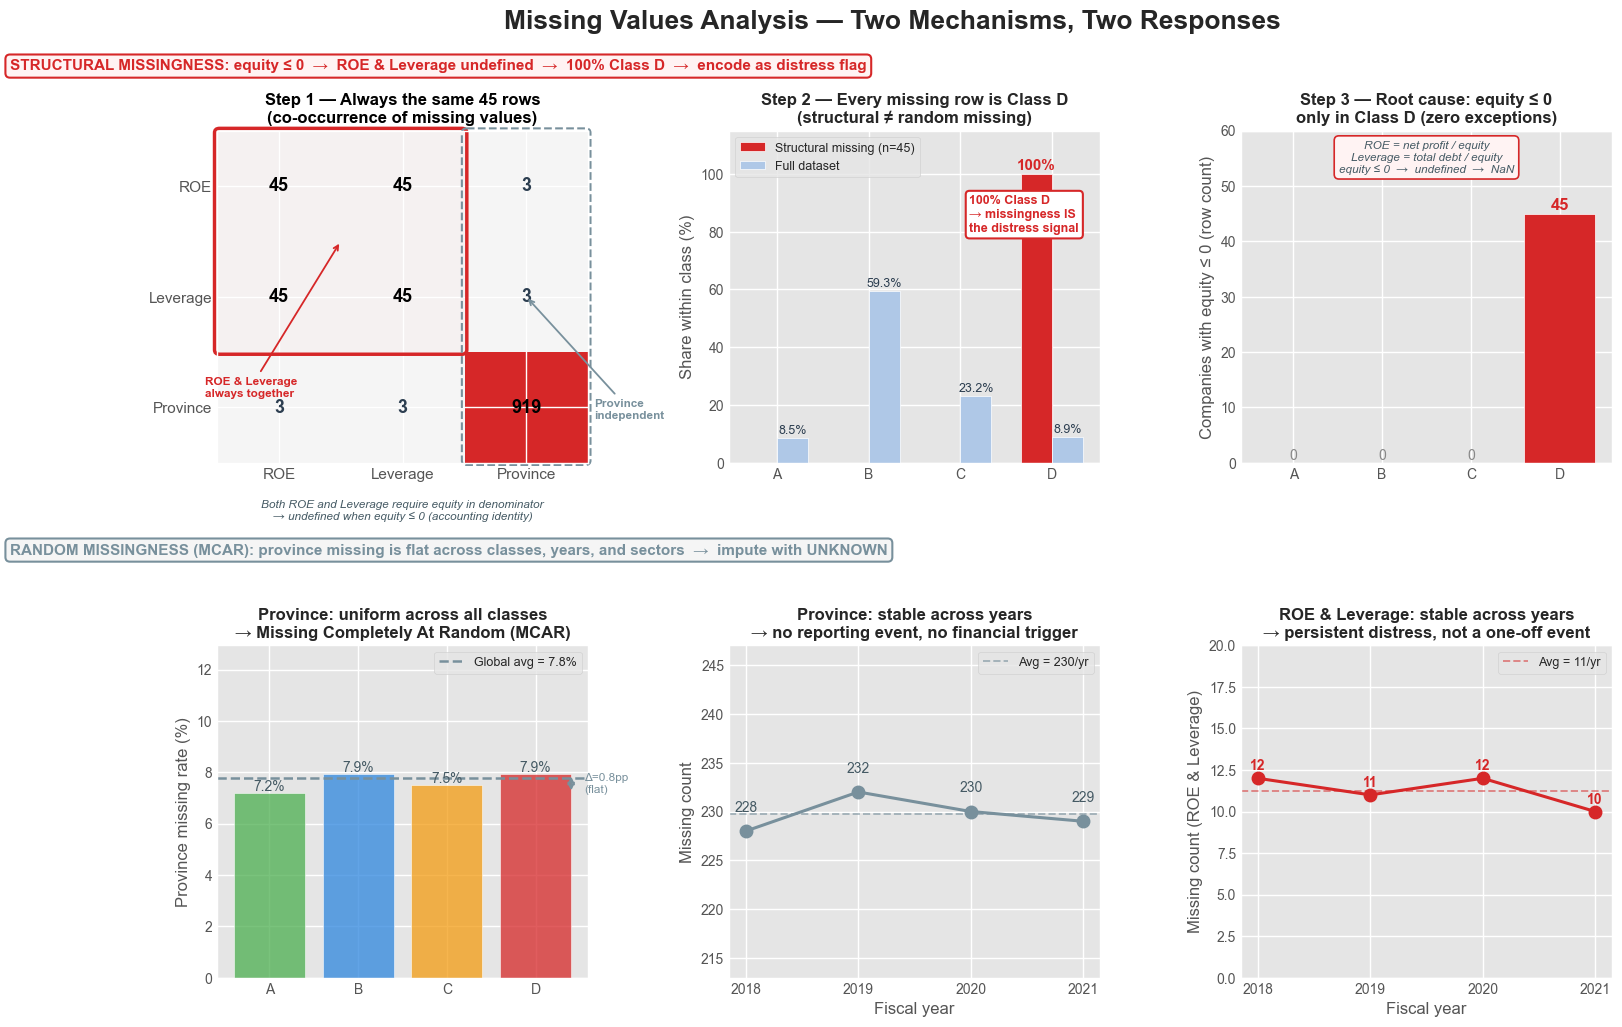

saved: missing_analysis_improved.png


In [124]:
# STATS
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct     = (missing / len(train_df) * 100).round(2)

assert (train_df["roe"].isnull() == train_df["leverage"].isnull()).all(), \
    "ROE and leverage nulls are NOT on the same rows — check data"

mask_structural = train_df["roe"].isnull()
n_structural    = mask_structural.sum()

# Negative equity → root cause
train_df["_neg_eq"] = (train_df["shareholders_equity"] < 0).astype(int)
neg_by_class = train_df.groupby(TARGET)["_neg_eq"].sum().reindex(CLASSES, fill_value=0)
pct_neg_eq_is_structural = (
    (train_df["_neg_eq"] == 1).sum() == n_structural
)  # should be True
train_df.drop(columns="_neg_eq", inplace=True)

# Class distribution: structural missing vs full dataset
class_dist_null = (
    train_df[mask_structural][TARGET]
    .value_counts(normalize=True).reindex(CLASSES, fill_value=0) * 100
)
class_dist_full = (
    train_df[TARGET]
    .value_counts(normalize=True).reindex(CLASSES, fill_value=0) * 100
)

# Co-occurrence matrix
features_to_check = ["roe", "leverage", "province"]
co_matrix = pd.DataFrame(index=features_to_check, columns=features_to_check, dtype=float)
for f1 in features_to_check:
    for f2 in features_to_check:
        co_matrix.loc[f1, f2] = (train_df[f1].isnull() & train_df[f2].isnull()).sum()

# Province: MCAR evidence
train_df["_prov_miss"] = train_df["province"].isnull().astype(int)
prov_rate_by_class = (
    train_df.groupby(TARGET)["_prov_miss"].mean()
    .reindex(CLASSES, fill_value=0) * 100
)
train_df.drop(columns="_prov_miss", inplace=True)

prov_by_year = train_df.groupby("fiscal_year")["province"].apply(lambda x: x.isnull().sum())
roe_by_year  = train_df.assign(_s=mask_structural.astype(int)).groupby("fiscal_year")["_s"].sum()
global_prov_rate = train_df["province"].isnull().mean() * 100
years = [str(y) for y in prov_by_year.index]

# STYLE

plt.style.use("ggplot")
palette        = {"A": "#4CAF50", "B": "#2E86DE", "C": "#F39C12", "D": "#D62728"}
class_colors   = [palette[c] for c in CLASSES]
structural_red = "#D62728"
mcar_grey      = "#78909C"
full_color     = "#AFC8E7"

# LAYOUT — 2 rows, asymmetric columns
# Row 1: [co-occurrence | class dist null vs full | neg equity by class]
# Row 2: [province by class | province by year | ROE/lev by year]

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# PLOT 1 — Co-occurrence matrix
# Story: ROE & leverage always co-missing (same 45 rows), province independent

cmap_co = mcolors.LinearSegmentedColormap.from_list(
    "miss", ["#f5f5f5", "#FFCDD2", structural_red]
)
ax1.imshow(co_matrix.values.astype(float), cmap=cmap_co, aspect="auto", vmin=0)

for i in range(3):
    for j in range(3):
        val   = int(co_matrix.values[i, j])
        color = "black" if val > 25 else "#2c3e50"
        ax1.text(j, i, str(val), ha="center", va="center",
                 fontsize=13, fontweight="bold", color=color)

ax1.set_xticks(range(3))
ax1.set_yticks(range(3))
ax1.set_xticklabels(["ROE", "Leverage", "Province"], fontsize=11)
ax1.set_yticklabels(["ROE", "Leverage", "Province"], fontsize=11)
ax1.set_title("Step 1 — Always the same 45 rows\n(co-occurrence of missing values)",
              fontweight="bold", fontsize=12, color="#1a1a2e" if False else "black")

# Red box around ROE/leverage 2×2 block
rect = FancyBboxPatch((-0.48, -0.48), 1.96, 1.96,
                      boxstyle="round,pad=0.04",
                      linewidth=2.5, edgecolor=structural_red, facecolor="none",
                      transform=ax1.transData, clip_on=False)
ax1.add_patch(rect)

# Grey dashed box around province row/col to show independence
rect2 = FancyBboxPatch((1.52, -0.48), 0.96, 2.96,
                       boxstyle="round,pad=0.04",
                       linewidth=1.5, edgecolor=mcar_grey,
                       linestyle="--", facecolor="none",
                       transform=ax1.transData, clip_on=False)
ax1.add_patch(rect2)

ax1.annotate("ROE & Leverage\nalways together",
             xy=(0.5, 0.5), xytext=(-0.6, 1.9),
             fontsize=8.5, color=structural_red, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=structural_red, lw=1.3))

ax1.annotate("Province\nindependent",
             xy=(2, 1), xytext=(2.55, 2.1),
             fontsize=8.5, color=mcar_grey, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=mcar_grey, lw=1.3))

ax1.text(0.5, -0.17,
         "Both ROE and Leverage require equity in denominator\n"
         "→ undefined when equity ≤ 0 (accounting identity)",
         transform=ax1.transAxes, ha="center", fontsize=8.5,
         color="#455A64", style="italic")

# PLOT 2 — Class distribution: structural missing vs full dataset
# Story: those 45 rows are 100% Class D — missing = distress signal

x = np.arange(len(CLASSES))
w = 0.34

bars_null = ax2.bar(x - w/2, class_dist_null.values, width=w,
                    color=structural_red, edgecolor="white",
                    label=f"Structural missing (n={n_structural})")
bars_full = ax2.bar(x + w/2, class_dist_full.values, width=w,
                    color=full_color, edgecolor="white",
                    label="Full dataset")

for i, (v1, v2) in enumerate(zip(class_dist_null.values, class_dist_full.values)):
    if v1 > 0:
        ax2.text(i - w/2, v1 + 1.5, f"{v1:.0f}%", ha="center",
                 fontsize=11, fontweight="bold", color=structural_red)
    if v2 > 2:
        ax2.text(i + w/2, v2 + 1.5, f"{v2:.1f}%", ha="center",
                 fontsize=9, color="#2c3e50")

# Highlight the D bar with a star annotation
ax2.annotate("100% Class D\n→ missingness IS\nthe distress signal",
             xy=(3 - w/2, 100), xytext=(2.1, 80),
             fontsize=9, color=structural_red, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=structural_red, lw=1.5),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=structural_red, lw=1.5))

ax2.set_xticks(x)
ax2.set_xticklabels(CLASSES)
ax2.set_ylim(0, 115)
ax2.set_ylabel("Share within class (%)")
ax2.set_title("Step 2 — Every missing row is Class D\n(structural ≠ random missing)",
              fontweight="bold", fontsize=12)
ax2.legend(fontsize=9, frameon=True, loc="upper left")

# PLOT 3 — Root cause: negative equity by class
# Story: equity ≤ 0 exists ONLY in Class D — that's why ROE/lev undefined

bars3 = ax3.bar(CLASSES, neg_by_class.values, color=class_colors, edgecolor="white")

for i, v in enumerate(neg_by_class.values):
    if v > 0:
        ax3.text(i, v + 0.8, str(int(v)), ha="center",
                 fontsize=12, fontweight="bold", color=structural_red)
    else:
        ax3.text(i, 0.5, "0", ha="center", fontsize=10, color="#888")

# Equation box explaining why
ax3.text(0.5, 0.97,
         "ROE = net profit / equity\n"
         "Leverage = total debt / equity\n"
         "equity ≤ 0  →  undefined  →  NaN",
         transform=ax3.transAxes, ha="center", va="top",
         fontsize=8.5, style="italic", color="#455A64",
         bbox=dict(boxstyle="round,pad=0.4", fc="#fff3f3", ec=structural_red, lw=1.2))

ax3.set_ylabel("Companies with equity ≤ 0 (row count)")
ax3.set_ylim(0, max(neg_by_class.values) + 15)
ax3.set_title("Step 3 — Root cause: equity ≤ 0\nonly in Class D (zero exceptions)",
              fontweight="bold", fontsize=12)

# PLOT 4 — Province missing rate by class (MCAR evidence)
# Story: flat across all classes → no financial signal

bars4 = ax4.bar(CLASSES, prov_rate_by_class.values, color=class_colors,
                edgecolor="white", alpha=0.75)

for i, v in enumerate(prov_rate_by_class.values):
    ax4.text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=10, color="#455A64")

ax4.axhline(y=global_prov_rate, color=mcar_grey, linestyle="--", linewidth=1.8,
            label=f"Global avg = {global_prov_rate:.1f}%")

# Bracket annotation showing flat range
min_r = prov_rate_by_class.values.min()
max_r = prov_rate_by_class.values.max()
ax4.annotate("", xy=(3.4, max_r), xytext=(3.4, min_r),
             arrowprops=dict(arrowstyle="<->", color=mcar_grey, lw=1.5))
ax4.text(3.55, (max_r + min_r) / 2,
         f"Δ={max_r-min_r:.1f}pp\n(flat)", fontsize=8.5,
         color=mcar_grey, va="center")

ax4.set_ylabel("Province missing rate (%)")
ax4.set_ylim(0, max(prov_rate_by_class.values) + 5)
ax4.set_title("Province: uniform across all classes\n→ Missing Completely At Random (MCAR)",
              fontweight="bold", fontsize=12)
ax4.legend(fontsize=9, frameon=True)

# PLOT 5 — Province missing by year (MCAR temporal stability)

ax5.plot(years, prov_by_year.values, marker="o", color=mcar_grey,
         linewidth=2.2, markersize=9)

for y, v in zip(years, prov_by_year.values):
    ax5.text(y, v + 2, str(v), ha="center", fontsize=10, color="#455A64")

ax5.axhline(y=prov_by_year.mean(), color=mcar_grey, linestyle="--",
            linewidth=1.4, alpha=0.6, label=f"Avg = {prov_by_year.mean():.0f}/yr")

ax5.set_ylabel("Missing count")
ax5.set_xlabel("Fiscal year")
ax5.set_ylim(min(prov_by_year.values) - 15, max(prov_by_year.values) + 15)
ax5.set_title("Province: stable across years\n→ no reporting event, no financial trigger",
              fontweight="bold", fontsize=12)
ax5.legend(fontsize=9, frameon=True)

# PLOT 6 — ROE/leverage missing by year (also stable → not event-driven)
ax6.plot(years, roe_by_year.values, marker="o", color=structural_red,
         linewidth=2.2, markersize=9)

for y, v in zip(years, roe_by_year.values):
    ax6.text(y, v + 0.5, str(v), ha="center", fontsize=10,
             fontweight="bold", color=structural_red)

ax6.axhline(y=roe_by_year.mean(), color=structural_red, linestyle="--",
            linewidth=1.4, alpha=0.5, label=f"Avg = {roe_by_year.mean():.0f}/yr")

ax6.set_ylabel("Missing count (ROE & Leverage)")
ax6.set_xlabel("Fiscal year")
ax6.set_ylim(0, max(roe_by_year.values) + 8)
ax6.set_title("ROE & Leverage: stable across years\n→ persistent distress, not a one-off event",
              fontweight="bold", fontsize=12)
ax6.legend(fontsize=9, frameon=True)

# GLOBAL TITLE + SECTION LABELS
fig.suptitle(
    "Missing Values Analysis — Two Mechanisms, Two Responses",
    fontsize=19, fontweight="bold", y=0.99
)

# Section banners
fig.text(0.01, 0.935,
         "STRUCTURAL MISSINGNESS: equity ≤ 0  →  ROE & Leverage undefined  →  100% Class D  →  encode as distress flag",
         fontsize=11, fontweight="bold", color=structural_red,
         bbox=dict(boxstyle="round,pad=0.3", fc="#fff3f3", ec=structural_red, lw=1.5))

fig.text(0.01, 0.495,
         "RANDOM MISSINGNESS (MCAR): province missing is flat across classes, years, and sectors  →  impute with UNKNOWN",
         fontsize=11, fontweight="bold", color=mcar_grey,
         bbox=dict(boxstyle="round,pad=0.3", fc="#f5f5f5", ec=mcar_grey, lw=1.5))


plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.savefig("missing_analysis_improved.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved: missing_analysis_improved.png")

### 3.3 Interpretation

The missing-value structure is highly asymmetric:

- **`roe` and `leverage` nulls are structural**, not accidental.
- They occur on the **same 45 observations**, all tied to **negative shareholders' equity**.
- Those rows are concentrated entirely in **class D**, making the null pattern itself a **distress signal** rather than a data-quality defect.
- By contrast, **`province` missingness is materially larger but behaviorally neutral**: its rate is stable across classes and fiscal years, which is consistent with a benign administrative omission.

This is the key preprocessing conclusion of the section:

| Missingness Type | Features | Interpretation | Recommended Handling |
|---|---|---|---|
| **Structural / informative** | `roe`, `leverage` | Nulls encode economically meaningful distress | Preserve signal with missing indicators + controlled imputation |
| **Benign / near-random** | `province` | Missingness behaves like a non-informative categorical gap | Impute as explicit category (`"UNKNOWN"`) |

> The important modeling mistake to avoid here is treating all nulls the same. In this dataset, some missing values are **predictive features**, while others are simply **categorical incompleteness**.

---
## Section 3 — Missing Values: Findings

### 3.4 Missingness Summary

Only **three columns** contain missing values, which means the dataset is exceptionally clean from a raw data-quality perspective.

| Column | Missing | % | Missingness Type | Core Interpretation |
|---|---:|---:|---|---|
| `province` | 919 | 7.77% | Benign / near-random | Administrative categorical gap |
| `roe` | 45 | 0.38% | Structural | Undefined under negative equity |
| `leverage` | 45 | 0.38% | Structural | Uninterpretable under negative equity |

**Key implication**
- No balance sheet or income statement line items are missing.
- The only meaningful nulls occur in **derived ratios**, not in the raw accounting variables.
- This is ideal for downstream feature engineering because the underlying financial statements remain intact.

---

### 3.5 `roe` and `leverage`: Structural Missingness, Not Data Loss

All 45 null `roe` observations are the **same rows** as the 45 null `leverage` observations, and all correspond to **negative shareholders' equity**.

This is economically important:

- `roe = net_profit / shareholders_equity` becomes unstable or misleading when equity is negative.
- `leverage = total_debt / shareholders_equity` becomes economically uninterpretable when the denominator is negative.
- The dataset correctly records these cases as `NaN` instead of exposing a mathematically valid but misleading ratio.

| Structural Fact | Modeling Meaning |
|---|---|
| `roe` null = `leverage` null on the same rows | One underlying condition drives both null patterns |
| All affected rows have negative equity | Missingness is economically grounded |
| Null rows are entirely concentrated in class D | Missingness itself is predictive |

**Analytical conclusion**
- These nulls are **not a data quality problem**.
- They are a **high-precision distress indicator**.

> Do **not** median-impute `roe` or `leverage` blindly. That would erase one of the clearest distress signals in the dataset.

---

### 3.6 Negative Equity Is a High-Precision, Low-Recall Distress Signal

Negative equity is **exclusive to class D**, which makes it a perfect precision signal when it appears.  
However, it covers only a small subset of all distressed observations.

| Signal Property | Interpretation |
|---|---|
| **Precision = extremely high** | When the signal fires, the company is effectively already in severe distress |
| **Recall = low** | Most class D companies do **not** have negative equity yet |
| **Economic meaning** | This is a **late-stage** distress marker, not an early warning feature |

This means the model should absolutely preserve this signal, but it should **not rely on it alone** for class D detection. The bulk of predictive power for distress must still come from earlier deterioration patterns such as worsening profitability, rising leverage, weakening liquidity, and adverse trends over time.

---

### 3.7 `province`: Benign Categorical Missingness

`province` has the largest missing share in absolute terms, but its pattern is behaviorally weak:

- Missingness is **roughly stable across classes**
- Missingness is **stable across fiscal years**
- There is no evidence that null `province` values concentrate in a particular risk state

This is therefore best interpreted as **administrative incompleteness**, not financial signal.

| Feature | Recommended Treatment | Why |
|---|---|---|
| `province` | Impute with `"UNKNOWN"` | Preserves rows and respects categorical structure |
| `province` | Do **not** mode-impute | Would inject a fake geographic signal |
| `province` | Do **not** drop rows | Missingness is too common and non-harmful |

---

### 3.8 Final Preprocessing Decisions for Missing Values

The missing-value policy should be **feature-specific**, not global.

1. **For `roe` and `leverage`:**
   - Create explicit missing-indicator features (`roe_is_null`, `leverage_is_null`)
   - Impute the numeric values in a way that preserves separation (e.g. sentinel or model-specific robust strategy)
   - Keep the underlying `shareholders_equity < 0` condition available as an additional distress flag

2. **For `province`:**
   - Replace nulls with a dedicated category such as `"UNKNOWN"`
   - Treat as a standard categorical level during encoding

3. **For all other features:**
   - No missing-value intervention is required at this stage

---

### Section 3 Conclusion

The dataset does **not** suffer from broad data-quality missingness. Instead, it contains a small but highly valuable set of **structural nulls** that encode severe financial distress, alongside one larger but largely harmless **categorical omission**.

→ Missing-value handling must therefore be **economically informed**, not mechanically uniform.

## 4. Descriptive Statistics

This section examines the numerical feature space before any transformations are applied. The objective is to understand **scale**, **dispersion**, **skewness**, and **outlier structure**, because these properties determine whether robust preprocessing, log transforms, winsorization, or tree-based models are more appropriate than raw linear modeling assumptions.

### 4.1 Diagnostic Scope

We evaluate numerical features along three dimensions:

1. **Summary statistics** — central tendency, spread, and extreme ranges.
2. **Distribution shape** — whether financial variables are symmetric or strongly right-skewed.
3. **Outlier structure** — whether extreme values are isolated anomalies or a structural property of firm-level accounting data.


### 4.2 Summary Statistics

We start with a full descriptive summary of the numerical variables. At this stage, the goal is not to interpret every column individually, but to identify the broad statistical signature of the dataset: wide scale heterogeneity, large dispersion in accounting totals, and the likely presence of extreme right tails.

In [125]:
# Hard distress thresholds
train_df["is_terminal_distress"] = (
    (train_df["debt_to_assets"] > 1) |
    (train_df["leverage"] > 50)      |
    (train_df["shareholders_equity"] < 0)
).astype(int)

terminal = train_df[train_df["is_terminal_distress"] == 1]
print("HARD DISTRESS THRESHOLDS")
print(f"Total terminal distress rows: {len(terminal)}")
print(f"Class distribution:\n{terminal[TARGET].value_counts()}")
print(f"\nOverlap check:")
print(f"  equity<0:           {(train_df['shareholders_equity'] < 0).sum()}")
print(f"  debt_to_assets>1:   {(train_df['debt_to_assets'] > 1).sum()}")
print(f"  leverage>50:        {(train_df['leverage'] > 50).sum()}")
print(f"  All same rows:      {train_df[train_df['shareholders_equity']<0].index.equals(train_df[train_df['debt_to_assets']>1].index)}")

# Ratio distributions by class (ANOVA + Kruskal-Wallis)
RATIO_COLS = ["roe", "roi", "profit_margin", "leverage",
              "debt_to_assets", "current_ratio", "quick_ratio"]

print("\nCLASS SEPARABILITY: RATIO FEATURES")
print(f"{'Feature':<20} {'A_med':>7} {'B_med':>7} {'C_med':>7} {'D_med':>7} {'KW_p':>10} {'Signal'}")
print("-" * 75)

kw_results = {}
for col in RATIO_COLS:
    groups = [train_df[train_df[TARGET] == c][col].dropna() for c in CLASSES]
    medians = [g.median() for g in groups]
    _, p = kruskal(*groups)
    kw_results[col] = p
    signal = "★★★" if p < 0.001 else ("★★" if p < 0.01 else ("★" if p < 0.05 else "—"))
    print(f"{col:<20} {medians[0]:>7.3f} {medians[1]:>7.3f} {medians[2]:>7.3f} {medians[3]:>7.3f} {p:>10.2e}  {signal}")

# Operating cost ratio by class
train_df["op_cost_ratio"] = train_df["production_costs"] / train_df["production_value"]
print("\nOPERATING COST RATIO BY CLASS")
print(train_df.groupby(TARGET)["op_cost_ratio"].median().round(4))
_, p_op = kruskal(*[train_df[train_df[TARGET]==c]["op_cost_ratio"].dropna() for c in CLASSES])
print(f"Kruskal-Wallis p={p_op:.2e}")

# Winsorization boundaries
print("\n WINSORIZATION BOUNDARIES (1st–99th percentile)")
for col in ["roe", "leverage"]:
    lo, hi = train_df[col].quantile([0.01, 0.99])
    n_clipped = ((train_df[col] < lo) | (train_df[col] > hi)).sum()
    print(f"{col:<12}  [{lo:.3f}, {hi:.3f}]  rows affected: {n_clipped}")

# Log-normality check for balance sheet vars
BS_COLS = ["total_assets", "production_value", "total_debt",
           "shareholders_equity", "current_assets", "total_fixed_assets"]

print("\nSKEWNESS: RAW vs LOG")
print(f"{'Feature':<25} {'raw_skew':>10} {'log_skew':>10} {'log_better'}")
print("-" * 55)
for col in BS_COLS:
    vals = train_df[col].dropna()
    pos_vals = vals[vals > 0]
    raw_skew = vals.skew()
    log_skew = np.log(pos_vals).skew()
    better = "✓" if abs(log_skew) < abs(raw_skew) else "✗"
    print(f"{col:<25} {raw_skew:>10.2f} {log_skew:>10.2f}   {better}")

HARD DISTRESS THRESHOLDS
Total terminal distress rows: 50
Class distribution:
financial_health_class
D    50
Name: count, dtype: int64

Overlap check:
  equity<0:           45
  debt_to_assets>1:   45
  leverage>50:        5
  All same rows:      True

CLASS SEPARABILITY: RATIO FEATURES
Feature                A_med   B_med   C_med   D_med       KW_p Signal
---------------------------------------------------------------------------
roe                    0.270   0.236   0.230  -0.105   0.00e+00  ★★★
roi                    0.158   0.116   0.088   0.007   0.00e+00  ★★★
profit_margin          0.087   0.067   0.046  -0.015   0.00e+00  ★★★
leverage               0.901   1.419   2.692   5.517   0.00e+00  ★★★
debt_to_assets         0.474   0.587   0.729   0.851   0.00e+00  ★★★
current_ratio          2.482   1.937   1.461   1.364   0.00e+00  ★★★
quick_ratio            1.489   1.162   0.876   0.818   0.00e+00  ★★★

OPERATING COST RATIO BY CLASS
financial_health_class
A    0.9019
B    0.9174
C   

The summary statistics confirm a typical financial-data profile:

- **Accounting totals operate on very different scales**, from small ratio-like variables to very large balance-sheet aggregates.
- Several variables show **extreme max values relative to their medians**, indicating heavy right tails.
- This means the raw numerical space is **not naturally well-behaved** for scale-sensitive models.

→ At this stage, the priority is not aggressive trimming, but understanding whether skewness and outliers reflect **real firm heterogeneity** rather than bad data.

In [126]:
def extract_optimal_thresholds(df, features, target, max_depth=2):
    optimal_rules = []
    # Prepariamo il target (Label Encoding necessario per l'albero)
    le = LabelEncoder()
    y = le.fit_transform(df[target])
    target_classes = le.classes_

    for col in features:
        # Pulizia dati per la singola feature
        df_sub = df[[col, target]].dropna()
        X_col = df_sub[[col]].values
        y_col = le.transform(df_sub[target])
        
        if len(df_sub) < 50: continue

        # Addestriamo un piccolo albero sulla singola variabile
        tree = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=0.05)
        tree.fit(X_col, y_col)
        
        # Estraiamo le soglie trovate dall'albero
        thresholds = tree.tree_.threshold
        # Rimuoviamo i valori di controllo ( -2 )
        thresholds = [t for t in thresholds if t != -2]
        
        for t in thresholds:
            # Testiamo la soglia in entrambe le direzioni
            for direction in ["below", "above"]:
                mask = df_sub[col] < t if direction == "below" else df_sub[col] > t
                n_cases = mask.sum()
                
                if n_cases < 50: continue
                
                # Calcolo distribuzione classi per questa soglia
                dist = df_sub[mask][target].value_counts(normalize=True).mul(100)
                dom_class = dist.idxmax()
                dom_pct = dist.max()
                
                optimal_rules.append({
                    "feature": col,
                    "threshold": round(t, 4),
                    "direction": direction,
                    "n": n_cases,
                    "dominant_class": dom_class,
                    "precision": round(dom_pct, 2),
                    "rule_string": f"{col} {'<' if direction == 'below' else '>'} {round(t, 4)}"
                })

    return pd.DataFrame(optimal_rules).sort_values(by=["precision", "n"], ascending=False)

# Esecuzione sulle tue feature core
features_to_audit = ["roe", "roi", "current_ratio", "debt_to_assets", "leverage", "profit_margin"]
dynamic_audit_df = extract_optimal_thresholds(train_df, features_to_audit, TARGET)

# Vediamo le top soglie per la Classe D (Insolvenza) e Classe A (Solidità)
print("AUTO-GENERATED THRESHOLDS (top precision)")
print(dynamic_audit_df[dynamic_audit_df["precision"] > 80].head(10))

AUTO-GENERATED THRESHOLDS (top precision)
           feature  threshold direction     n dominant_class  precision  \
0              roe    -0.0499     below   708              D     100.00   
19  debt_to_assets     0.8443     above   592              D      95.10   
28   profit_margin    -0.0051     below   825              D      90.79   
25        leverage     5.2147     above   590              D      90.51   
14  debt_to_assets     0.6999     below  8260              B      84.95   
20        leverage     2.3331     below  8260              B      84.95   
4              roi     0.0220     below   876              D      84.70   

                rule_string  
0             roe < -0.0499  
19  debt_to_assets > 0.8443  
28  profit_margin < -0.0051  
25        leverage > 5.2147  
14  debt_to_assets < 0.6999  
20        leverage < 2.3331  
4               roi < 0.022  


import plotly.graph_objects as go
import os

# 1. UPDATED COLOR PALETTE
colors = {"A": "#4caf50", "B": "#2196f3", "C": "#ff9800", "D": "#d32f2f"}

# 2. CREAZIONE VISUALIZZAZIONE 
fig = go.Figure(data=[go.Table( 
    columnwidth=[180, 60, 80, 80, 180], 
    header=dict( 
        values=["<b>Detected Rule</b>", "<b>Sample (n)</b>", "<b>Target Class</b>", "<b>Precision</b>", "<b>Audit Action</b>"], 
        # Light grey background for the header 
        fill_color="#F8F9FA",  
        # Dark slate text for high contrast 
        font=dict(color="black", size=13), 
        align="center", 
        height=38, 
        # Subtle border line 
        line_color="black" 
    ), 
    cells=dict( 
        values=[ 
            report_df["rule_string"], 
            report_df["n"], 
            report_df["dominant_class"], 
            report_df["precision"].apply(lambda x: f"{x:.1f}%"), 
            report_df["action"] 
        ], 
        # Pure white background for all cells 
        fill_color="white", 
        # Colors applied only to the text based on dominant_class
        font=dict(color=[[colors.get(c, "black") for c in report_df["dominant_class"]]], size=12), 
        align="center", 
        height=33, 
        # Subtle border line between rows 
        line_color="black" 
    ) 
)]) 

fig.update_layout( 
    title=dict( 
        text="<b>Statistically Optimized Thresholds: Data-Driven Audit</b><br>" 
             "<span style='font-size:13px;color:black;'>Thresholds detected via Decision Tree (Depth 2). " 
             "Precision indicates the confidence of the rule in isolating the dominant class.</span>", 
        font=dict(size=18, color="black"), 
    ), 
    margin=dict(t=100, l=15, r=15, b=15), 
    width=900, 
    height=500, 
    paper_bgcolor="white" 
) 

# Salvataggio e Show 
p_final = os.path.join(OUTPUT_PATH, "automated_threshold_audit.png") 
fig.write_image(p_final, scale=2) 
fig.show()

## Threshold Audit — Key Findings

### Structural asymmetry of the target variable
The classification task is **not symmetric across classes**. Class D has 8 hard threshold
rules with 100% precision, while Class A has zero rules above 80%. This confirms that the
target variable has deterministic boundaries at the extremes and a soft, overlapping center.

### Class D — deterministic signal
All distress conditions are algebraically linked:
- `equity ≤ 0` and `DTA ≥ 1` capture identical cases (accounting identity)
- `roe < -0.05` is the single most powerful rule: 708 cases, 67% of all Class D
- Rules are **overlapping subsets**, not partitions — coverage percentages are not additive
- Engineering decision: create boolean flags for rules with n ≥ 50 and precision = 100%
- Exception: `net_profit < 0` (80% precision, n=1009) → keep as continuous feature

### Class B — single rule dominance
`debt_to_assets < 0.7` is the most informative feature in the dataset:
- Appears as best separator on **two consecutive boundaries** (A↔B: 73pp, B↔C: 82pp)
- Engineering decision: engineer `dta_below_070` as boolean feature

### Class C — no positive rules
No single threshold identifies Class C above 60% precision.
Class C is defined by **exclusion**: not healthy enough for B, not distressed enough for D.
The model will classify C as the residual after identifying A, B, and D.
Expected consequence: most misclassification errors will fall on the B↔C boundary.

### Class A — combination-dependent
Class A cannot be identified by any single threshold rule.
It requires **feature interactions** — likely high ROE + low DTA + positive margins combined.
Do not engineer a single `is_likely_A` flag: it would introduce noisy signal.

### Generalization caveat
Boolean flags derived from training-set thresholds must be validated on the 2021
holdout fold. If feature importance of these flags drops significantly out-of-sample,
the thresholds may reflect training distribution artifacts rather than true structure.
Monitor: `roe_below_005`, `dta_above_085`, `dta_below_070`, `op_income_neg`.


The distribution plots show that skewness is not a minor artifact but a **structural property** of the dataset:

- **Balance-sheet and scale variables are heavily right-skewed**, with a long tail of much larger firms.
- The bulk of observations is compressed near the lower end of the range, while a small number of firms occupy the extreme upper tail.
- This pattern is economically plausible and should be expected in heterogeneous firm populations.

| Variable Type | Typical Shape | Modeling Implication |
|---|---|---|
| **Size / balance-sheet totals** | Strong right skew | Consider log transforms or tree-based models |
| **Ratio variables** | Often more centered but still noisy | Check separately; may still need robust scaling |
| **Mixed financial indicators** | Can contain both skewness and instability | Avoid assuming Gaussian behavior |

> Heavy skew in financial data is not automatically a cleaning problem. In many cases, it reflects the real size distribution of firms rather than spurious observations.

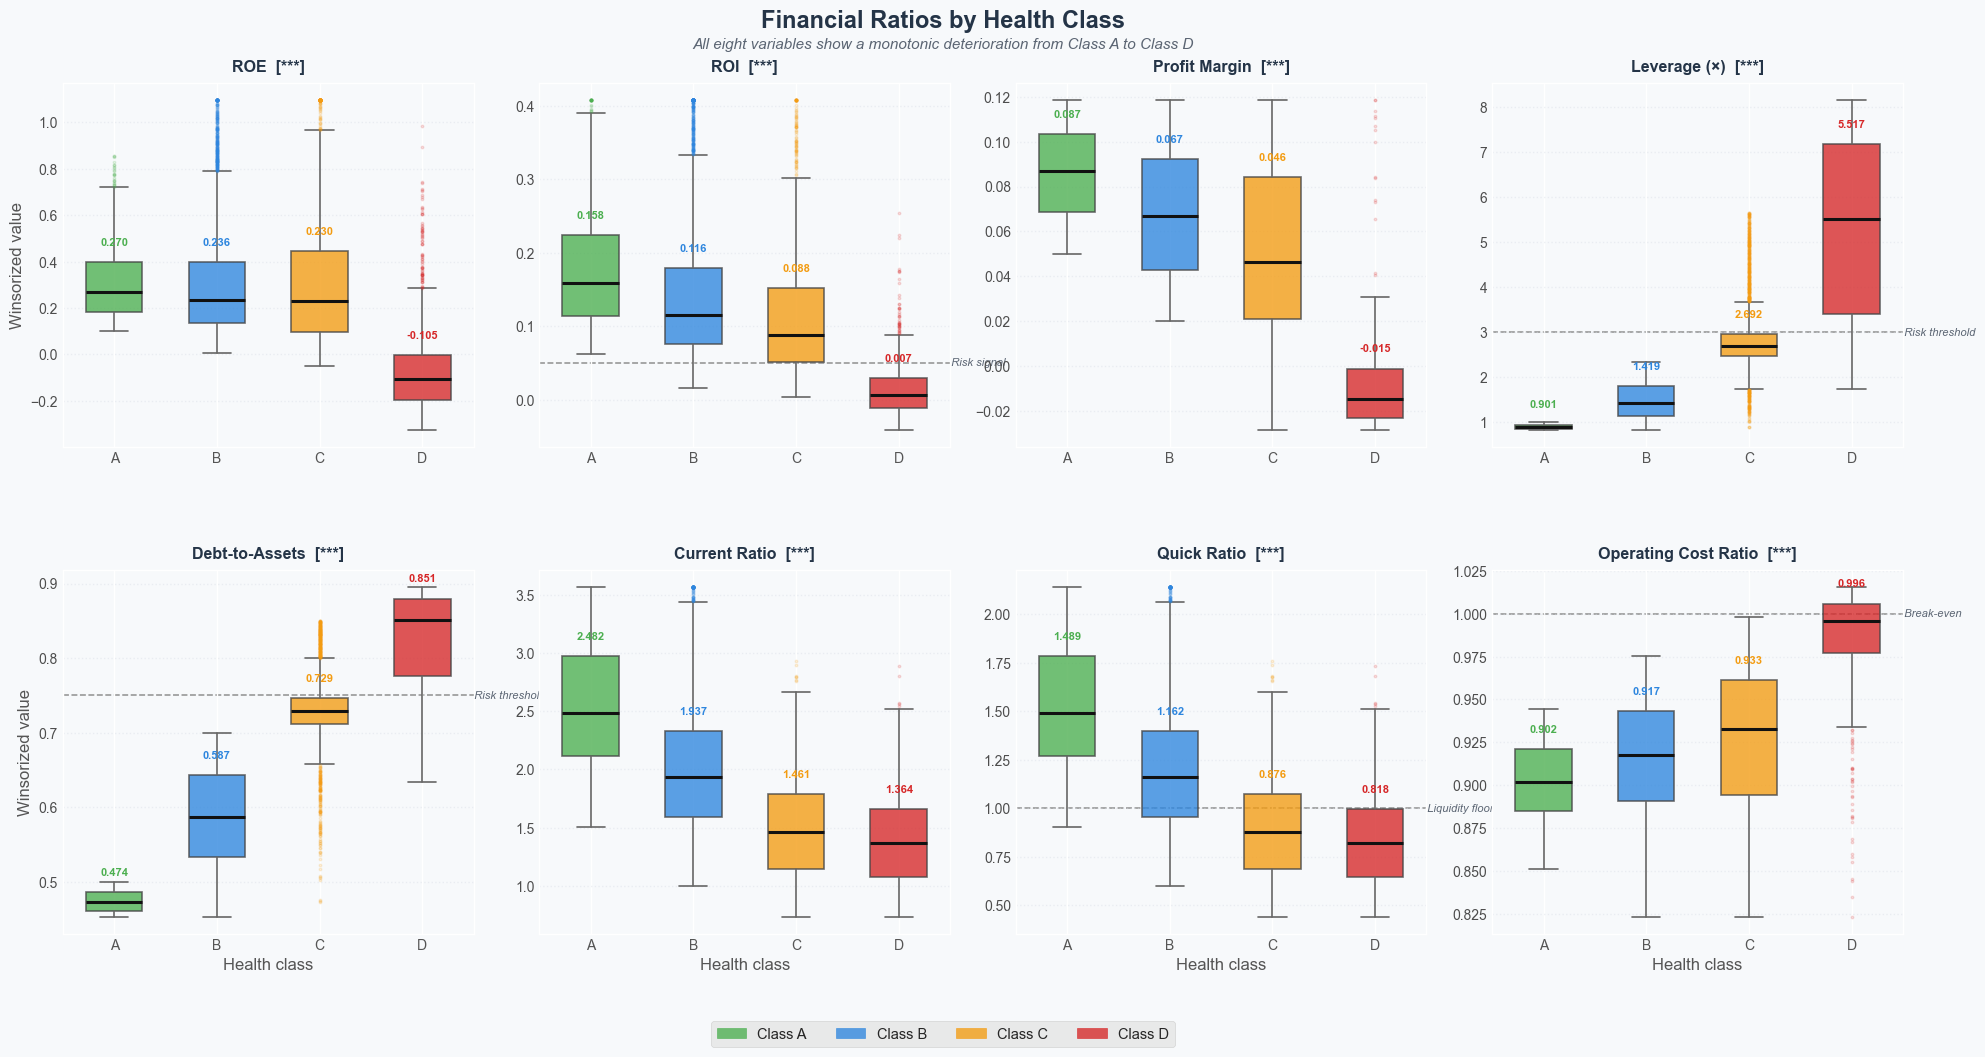

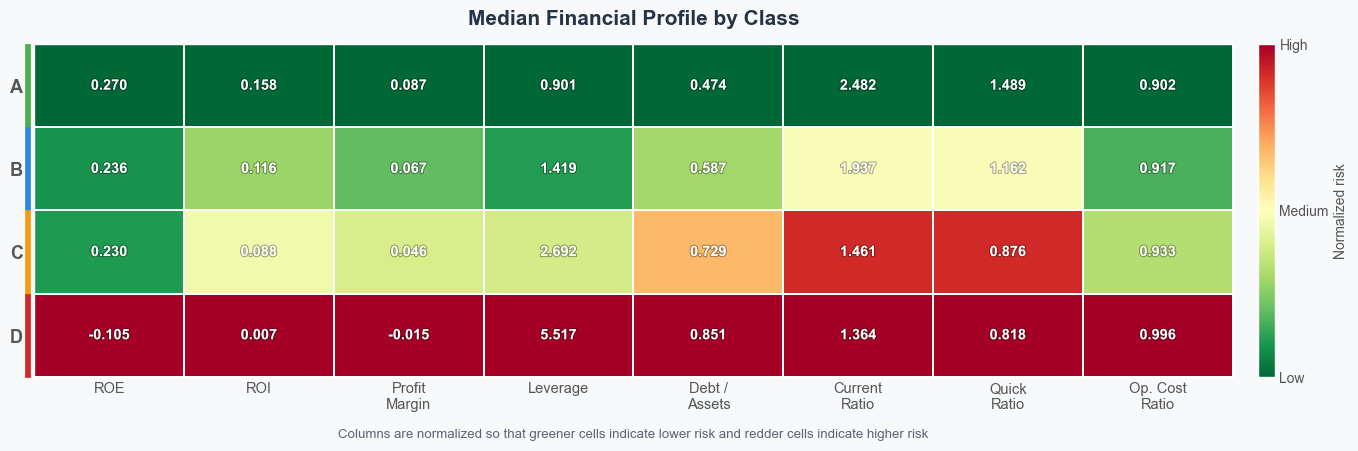

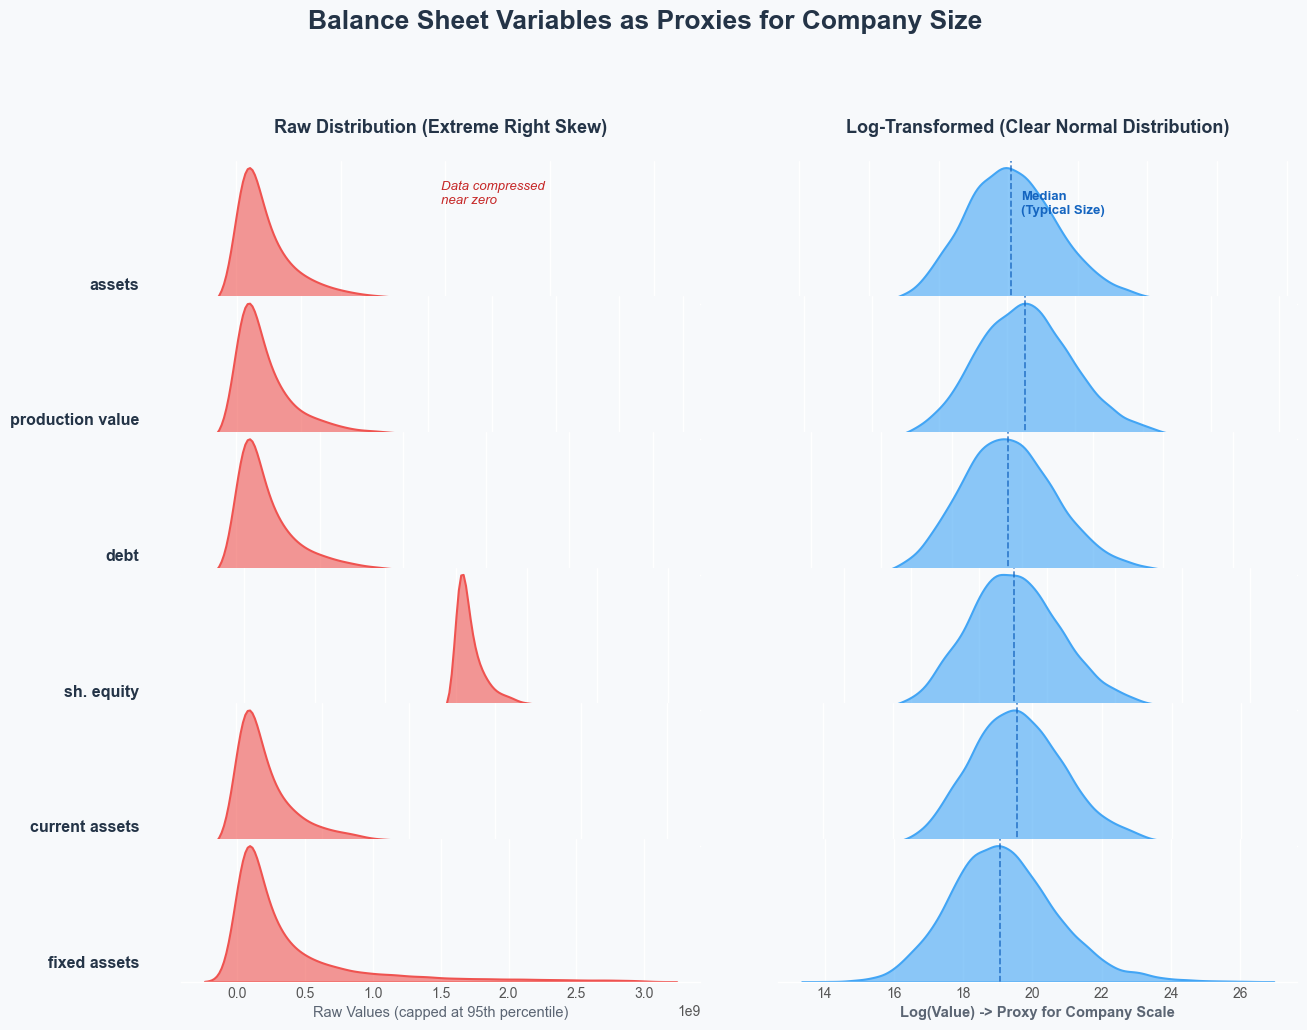

In [127]:
# Prep
train_df["op_cost_ratio"] = train_df["production_costs"] / train_df["production_value"]
ALL_COLS = RATIO_COLS + ["op_cost_ratio"]
kw_results["op_cost_ratio"] = p_op

plot_df = train_df.copy()
for col in ALL_COLS:
    lo, hi = plot_df[col].quantile([0.01, 0.99])
    plot_df[col] = plot_df[col].clip(lo, hi)

YLABELS = {
    "roe": "ROE",
    "roi": "ROI",
    "profit_margin": "Profit Margin",
    "leverage": "Leverage (×)",
    "debt_to_assets": "Debt-to-Assets",
    "current_ratio": "Current Ratio",
    "quick_ratio": "Quick Ratio",
    "op_cost_ratio": "Operating Cost Ratio",
}

THRESHOLDS = {
    "leverage": (3.0, "Risk threshold"),
    "debt_to_assets": (0.75, "Risk threshold"),
    "quick_ratio": (1.0, "Liquidity floor"),
    "op_cost_ratio": (1.0, "Break-even"),
    "roi": (0.05, "Risk signal"),
}

COL_LABELS = {
    "roe": "ROE",
    "roi": "ROI",
    "profit_margin": "Profit\nMargin",
    "leverage": "Leverage",
    "debt_to_assets": "Debt /\nAssets",
    "current_ratio": "Current\nRatio",
    "quick_ratio": "Quick\nRatio",
    "op_cost_ratio": "Op. Cost\nRatio",
}

FLIP_COLS = ["roe", "roi", "profit_margin", "current_ratio", "quick_ratio"]

short_lbls = [
    c.replace("total_", "")
     .replace("shareholders_", "sh.\n")
     .replace("_", "\n")
    for c in BS_COLS
]

# FIGURE 1 — BOXPLOTS DASHBOARD
fig, axes = plt.subplots(2, 4, figsize=(20, 10.5))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for i, col in enumerate(ALL_COLS):
    ax = axes[i]
    ax.set_facecolor(BG)

    data_by_class = [plot_df.loc[plot_df[TARGET] == c, col].dropna() for c in CLASSES]
    medians = [d.median() for d in data_by_class]

    bp = ax.boxplot(
        data_by_class,
        patch_artist=True,
        widths=0.55,
        medianprops=dict(color="#111111", linewidth=2.2),
        whiskerprops=dict(linewidth=1.2, color="#666666"),
        capprops=dict(linewidth=1.2, color="#666666"),
        flierprops=dict(marker="o", markersize=1.8, alpha=0.15, linestyle="none"),
        boxprops=dict(linewidth=1.2, edgecolor="#444444"),
    )

    for patch, cls in zip(bp["boxes"], CLASSES):
        patch.set_facecolor(palette[cls])
        patch.set_alpha(0.78)

    for flier, cls in zip(bp["fliers"], CLASSES):
        flier.set_markerfacecolor(palette[cls])
        flier.set_markeredgecolor(palette[cls])

    # Thresholds
    if col in THRESHOLDS:
        val, label = THRESHOLDS[col]
        ax.axhline(val, color="#7a7a7a", linestyle="--", linewidth=1.15, alpha=0.8, zorder=0)
        ax.text(
            4.45, val, f"  {label}",
            va="center", ha="left",
            fontsize=8, color=SUBTLE, style="italic"
        )

    # Median labels
    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * 0.08
    for j, (d, cls) in enumerate(zip(data_by_class, CLASSES), start=1):
        q3 = np.percentile(d, 75)
        ax.text(
        j,
        q3 + (y_max - y_min) * 0.04,
        f"{d.median():.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color=palette[cls]
    )

    p = kw_results[col]
    stars = "***" if p < 0.001 else ("**" if p < 0.01 else "*")

    ax.set_title(f"{YLABELS[col]}  [{stars}]", fontsize=11.5, pad=8, color=TEXT)
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(CLASSES)
    ax.grid(axis="y", linestyle=":", alpha=0.45, color=GRID)
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", colors="#4d4d4d")

    # y-label
    if i % 4 == 0:
        ax.set_ylabel("Winsorized value")
    else:
        ax.set_ylabel("")

    # x-label
    if i >= 4:
        ax.set_xlabel("Health class")
    else:
        ax.set_xlabel("")

legend_patches = [
    mpatches.Patch(color=palette[c], alpha=0.78, label=f"Class {c}")
    for c in CLASSES
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=4,
    fontsize=10.5,
    frameon=True,
    bbox_to_anchor=(0.5, -0.005)
)

fig.suptitle(
    "Financial Ratios by Health Class",
    fontsize=17,
    fontweight="bold",
    y=0.99,
    color=TEXT
)
fig.text(
    0.5, 0.953,
    "All eight variables show a monotonic deterioration from Class A to Class D",
    ha="center", fontsize=11, color=SUBTLE, style="italic"
)

plt.subplots_adjust(top=0.92, bottom=0.11, left=0.06, right=0.98, hspace=0.34, wspace=0.16)
plt.savefig(FIG_DIR / "ratio_boxplots_improved.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# FIGURE 2 — HEATMAP OF MEDIANS
median_table = pd.DataFrame(
    {
        col: [plot_df.loc[plot_df[TARGET] == c, col].median() for c in CLASSES]
        for col in ALL_COLS
    },
    index=CLASSES
)

normed = median_table.copy()
for col in normed.columns:
    lo, hi = normed[col].min(), normed[col].max()
    normed[col] = (normed[col] - lo) / (hi - lo + 1e-9)

for col in FLIP_COLS:
    normed[col] = 1 - normed[col]

fig, ax = plt.subplots(figsize=(14.5, 5.2))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# coordinate grid for pcolormesh
X = np.arange(len(ALL_COLS) + 1)
Y = np.arange(len(CLASSES) + 1)

mesh = ax.pcolormesh(
    X,
    Y,
    normed.values,
    cmap=plt.cm.RdYlGn_r,
    vmin=0,
    vmax=1,
    edgecolors="white",
    linewidth=1.2,
    shading="flat"
)

# put first row at the top
ax.invert_yaxis()

# values INSIDE the rectangles only
for i, cls in enumerate(CLASSES):
    for j, col in enumerate(ALL_COLS):
        raw = median_table.loc[cls, col]
        t = ax.text(
            j + 0.5, i + 0.5, f"{raw:.3f}",
            ha="center",
            va="center",
            fontsize=10.5,
            fontweight="bold",
            color="white"
        )
        t.set_path_effects([pe.withStroke(linewidth=1.5, foreground="black", alpha=0.35)])

# single class strip on the left
for i, cls in enumerate(CLASSES):
    ax.add_patch(
        plt.Rectangle(
            (-0.06, i), 0.035, 1,
            color=palette[cls],
            transform=ax.transData,
            clip_on=False,
            zorder=5
        )
    )

# ticks centered in each cell
ax.set_xticks(np.arange(len(ALL_COLS)) + 0.5)
ax.set_xticklabels([COL_LABELS[c] for c in ALL_COLS], fontsize=10.5)

ax.set_yticks(np.arange(len(CLASSES)) + 0.5)
ax.set_yticklabels(CLASSES, fontsize=13, fontweight="bold")
ax.tick_params(axis="y", pad=8)

ax.tick_params(length=0)

cbar = plt.colorbar(mesh, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Normalized risk", fontsize=10)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["Low", "Medium", "High"])

ax.set_title(
    "Median Financial Profile by Class",
    fontsize=15,
    fontweight="bold",
    pad=14,
    color=TEXT
)

ax.set_xlabel(
    "Columns are normalized so that greener cells indicate lower risk and redder cells indicate higher risk",
    fontsize=9.5,
    color=SUBTLE,
    labelpad=12
)

plt.subplots_adjust(top=0.86, bottom=0.22, left=0.09, right=0.96)
plt.savefig(FIG_DIR / "ordinal_gradient_improved.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


# FIGURE 3 — LOG TRANSFORM BEFORE / AFTER

# Aumentiamo leggermente l'altezza per riga e riduciamo l'overlap esagerato
fig, axes = plt.subplots(
    len(BS_COLS), 2, 
    figsize=(14.5, 1.8 * len(BS_COLS)), 
    gridspec_kw={"hspace": -0.05} # Overlap più morbido per evitare che il testo si schiacci
)
fig.patch.set_facecolor(BG)

# Titoli delle colonne spostati più in alto
axes[0, 0].set_title("Raw Distribution (Extreme Right Skew)", fontsize=13, fontweight="bold", color=TEXT, pad=20)
axes[0, 1].set_title("Log-Transformed (Clear Normal Distribution)", fontsize=13, fontweight="bold", color=TEXT, pad=20)

for i, col in enumerate(BS_COLS):
    ax_raw = axes[i, 0]
    ax_log = axes[i, 1]
    
    ax_raw.set_facecolor(BG)
    ax_log.set_facecolor(BG)
    
    # Rimuovi bordi e assi Y inutili
    for ax in [ax_raw, ax_log]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", length=0)
        ax.set_yticks([]) 
    
    vals = train_df[col].dropna()
    
    # Per il raw plot, tagliamo al 95° percentile altrimenti non si vede nulla
    val_95 = vals.quantile(0.95)
    raw_plot_data = vals[vals < val_95]
    
    # Per il log plot, usiamo log1p
    log_vals = np.log1p(vals[vals > 0])
    
    # --- PLOT RAW ---
    sns.kdeplot(
        raw_plot_data, 
        ax=ax_raw, 
        fill=True, 
        color="#ef5350", 
        alpha=0.6, 
        linewidth=1.5
    )
    
    # --- PLOT LOG ---
    sns.kdeplot(
        log_vals, 
        ax=ax_log, 
        fill=True, 
        color="#42a5f5", 
        alpha=0.6, 
        linewidth=1.5
    )
    
    median_val = log_vals.median()
    ax_log.axvline(median_val, color="#1565c0", linestyle="--", linewidth=1.2, alpha=0.8)
    
    if i == 0:
        y_max = ax_log.get_ylim()[1]
        ax_log.text(
            median_val + 0.3, y_max * 0.7, 
            "Median\n(Typical Size)", 
            color="#1565c0", fontsize=9.5, fontweight="bold", va="center"
        )
        
        # Etichetta esplicativa sul Raw
        ax_raw.text(
            0.5, 0.7, 
            "Data compressed\nnear zero", 
            transform=ax_raw.transAxes, color="#c62828", fontsize=9.5, style="italic"
        )
    
    # Etichette delle variabili (a sinistra)
    ax_raw.text(
        -0.08, 0.1, short_lbls[i].replace("\n", " "), 
        transform=ax_raw.transAxes, 
        fontsize=11.5, 
        fontweight="bold", 
        color=TEXT, 
        ha="right"
    )

    # Gestione assi X
    if i < len(BS_COLS) - 1:
        ax_raw.set_xlabel("")
        ax_raw.set_xticklabels([])
        ax_log.set_xlabel("")
        ax_log.set_xticklabels([])
    else:
        ax_raw.set_xlabel("Raw Values (capped at 95th percentile)", fontsize=10.5, color=SUBTLE)
        ax_log.set_xlabel("Log(Value) -> Proxy for Company Scale", fontsize=10.5, color=SUBTLE, fontweight="bold")

# Titolo Principale
fig.suptitle(
    "Balance Sheet Variables as Proxies for Company Size",
    fontsize=19,
    fontweight="bold",
    y=0.98,
    color=TEXT
)

plt.subplots_adjust(top=0.84, bottom=0.08, left=0.18, right=0.95, wspace=0.15)
plt.savefig(FIG_DIR / "size_proxy_ridgeplot_v2.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


### 4.4 Outlier Diagnostics

To assess whether extreme values are isolated anomalies or a persistent structural feature, we inspect winsorized boxplots (1st–99th percentile). Winsorization is used here **only for visualization**, so the central distribution remains readable without letting a few extreme observations dominate the scale.

This distinction matters:

- If outliers disappear after mild winsorization, they are likely **rare extremes**.
- If long whiskers and wide spreads remain even after winsorization, the dataset is structurally heavy-tailed.
- In financial classification tasks, this usually supports **robust preprocessing** rather than aggressive row deletion.



### 4.5 Interpretation

The boxplots confirm that extreme values are **persistent**, not incidental:

- Even after **1–99% winsorization**, many variables still retain wide spreads and long whiskers.
- This means the dataset is not just affected by a few isolated outliers; it is **structurally heavy-tailed**.
- In other words, large dispersion is part of the economic reality of the sample, not merely a data-entry problem.

**Modeling implication**

- Avoid indiscriminate row deletion based on standard outlier rules.
- Prefer **robust scaling**, **log transforms for strictly positive size variables**, and model families that tolerate non-Gaussian inputs well.
- Tree-based learners are naturally well-suited to this structure, while linear models will require more careful preprocessing.

---
 ## Section 4 — Descriptive Statistics: Findings

### 4.6 Summary of Numerical Feature Behavior

The numerical feature space shows a classic firm-level financial-data pattern: **large scale heterogeneity, strong right skew in size variables, and persistent heavy tails even after mild winsorization**.

| Diagnostic | Main Result | Interpretation |
|---|---|---|
| **Summary statistics** | Very large gaps between medians and maxima | Several variables are strongly right-skewed |
| **Distribution plots** | Mass concentrated near lower ranges with long upper tails | Firm size is highly heterogeneous |
| **Winsorized boxplots** | Wide spreads remain after 1–99% trimming | Extreme values are structural, not isolated noise |

---

### 4.7 What This Means for Modeling

The descriptive analysis supports the following preprocessing logic:

1. **Do not assume Gaussian structure**
   - Raw numerical variables are not naturally symmetric or homoscedastic.

2. **Treat outliers as economically meaningful unless proven otherwise**
   - Extreme values are common in accounting data and often reflect genuine firm heterogeneity.

3. **Use transformation selectively**
   - Apply log transforms only to strictly positive scale variables where compression improves separability.
   - Avoid mechanically transforming unstable ratio features.

4. **Prefer robust preprocessing for linear models**
   - Robust scaling is more defensible than standard scaling in the presence of heavy tails.

5. **Expect tree-based models to be naturally advantaged**
   - The observed distributional structure is well aligned with non-linear, threshold-based learners.

---

### 4.8 Final Section Conclusion

This section shows that the dataset is **numerically complex but not numerically broken**. The main challenge is not missingness or obvious corruption, but the combination of **heterogeneous firm scale**, **strong skewness**, and **structural heavy tails**.

→ The correct response is **economically aware preprocessing**, not aggressive sanitization.


## 5. Correlation Analysis

Correlation analysis is used here to distinguish **economically expected relationships** from **true redundancy**. In financial datasets, many variables move together because of accounting identities, shared denominators, or firm-size effects, so high correlation is not automatically a problem. The objective is therefore not to drop correlated features mechanically, but to identify where correlation reflects duplicated information versus where it preserves distinct financial meaning.

### 5.1 Diagnostic Scope

This section focuses on three questions:

1. **How structured is the global dependence pattern** among numerical variables?
2. **Which relationships are strong enough to deserve explicit review?**
3. **Which correlations imply redundancy**, and which should be retained because they still represent different economic mechanisms?

### 5.2 Correlation Setup

Before plotting the correlation structure, we define the export path and shared plotting settings used across the diagnostics below. The actual analytical focus begins with the full correlation heatmap.

In [128]:
NUM_COLS = [
    "total_fixed_assets", "current_assets", "shareholders_equity",
    "total_debt", "short_term_debt", "long_term_debt",
    "production_value", "production_costs", "operating_income",
    "net_profit_loss",
    "roe", "roi", "leverage", "current_ratio", "quick_ratio",
    "debt_to_assets", "profit_margin",
    "years_in_business",
]
NUM_COLS = [c for c in NUM_COLS if c in train_df.columns]

LABELS = {
    "total_fixed_assets": "Fixed assets",
    "current_assets": "Current assets",
    "shareholders_equity": "Equity",
    "total_debt": "Total debt",
    "short_term_debt": "Short-term debt",
    "long_term_debt": "Long-term debt",
    "production_value": "Production value",
    "production_costs": "Production costs",
    "operating_income": "Operating income",
    "net_profit_loss": "Net profit/loss",
    "roe": "ROE",
    "roi": "ROI",
    "leverage": "Leverage",
    "current_ratio": "Current ratio",
    "quick_ratio": "Quick ratio",
    "debt_to_assets": "Debt / assets",
    "profit_margin": "Profit margin",
    "years_in_business": "Years in business",
}

corr = train_df[NUM_COLS].corr(method="spearman")

# mask upper triangle only
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

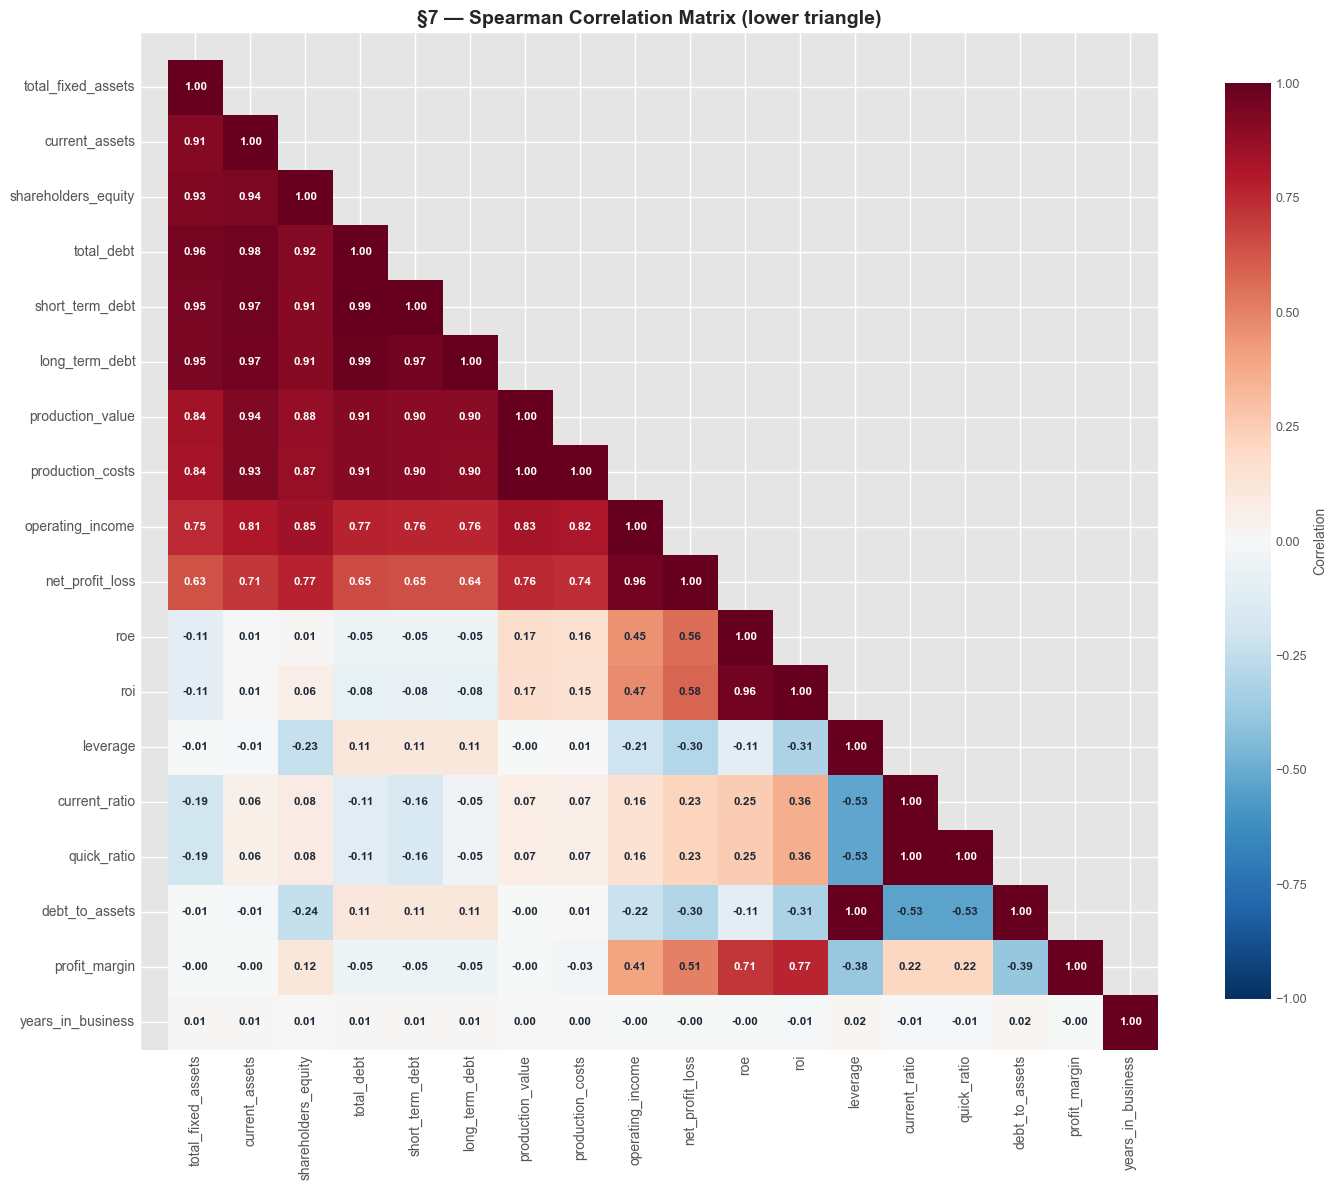

In [129]:
fig, ax = plt.subplots(figsize=(15, 12))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0,
    square=True,
    cbar_kws={"shrink": 0.90},
    annot_kws={"size": 8.5, "weight": "bold"},
    ax=ax
)

# borders
ax.set_xticks(np.arange(len(corr) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(corr) + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# tick labels
ax.set_xticklabels(corr.columns, rotation=90, fontsize=10)
ax.set_yticklabels(corr.index, rotation=0, fontsize=10)

# title
ax.set_title(
    "§7 — Spearman Correlation Matrix (lower triangle)",
    fontsize=14,
    fontweight="bold"
)

# annotation
for text in ax.texts:
    s = text.get_text().strip()
    if not s:
        continue
    try:
        val = float(s)
    except ValueError:
        continue
    text.set_color("white" if abs(val) >= 0.60 else "#1f2937")

# colorbar
cbar = ax.collections[0].colorbar
cbar.set_label("Correlation", fontsize=10)
cbar.ax.tick_params(labelsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "eda_s7_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

The heatmap shows that correlation is **structured rather than pervasive**:

- Strong relationships are concentrated in a limited number of **feature families**, not spread uniformly across the entire numerical space.
- Several high-correlation areas are **economically expected**, especially where accounting quantities scale together.
- This suggests the dataset contains **localized redundancy**, but not a universally collinear feature space.

→ The next step is to isolate only the strongest relationships and assess whether they represent true duplicates or economically distinct signals.

### 5.4 High-Correlation Pairs

To make the redundancy check explicit, we now isolate only the strongest numerical relationships using a high-correlation threshold. This helps separate broad visual structure from the specific feature pairs that may require pruning, grouping, or closer economic interpretation.

In [130]:
HIGH_THR = 0.85
pairs = []
for i in range(len(corr.columns)):
    for j in range(i):
        r = corr.iloc[i, j]
        if abs(r) >= HIGH_THR:
            pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

pairs.sort(key=lambda x: -abs(x[2]))

print(f"High-correlation pairs (|r| ≥ {HIGH_THR}):")
if pairs:
    for a, b, r in pairs:
        print(f"  {a:30s} ↔  {b:30s}  r={r:+.3f}")
else:
    print("  None found.")

High-correlation pairs (|r| ≥ 0.85):
  production_costs               ↔  production_value                r=+1.000
  quick_ratio                    ↔  current_ratio                   r=+1.000
  debt_to_assets                 ↔  leverage                        r=+1.000
  short_term_debt                ↔  total_debt                      r=+0.993
  long_term_debt                 ↔  total_debt                      r=+0.989
  total_debt                     ↔  current_assets                  r=+0.976
  short_term_debt                ↔  current_assets                  r=+0.969
  long_term_debt                 ↔  short_term_debt                 r=+0.966
  long_term_debt                 ↔  current_assets                  r=+0.965
  net_profit_loss                ↔  operating_income                r=+0.964
  roi                            ↔  roe                             r=+0.962
  total_debt                     ↔  total_fixed_assets              r=+0.960
  short_term_debt                ↔  tot

### 5.5 Interpretation

The strongest pairs should be interpreted economically before any feature is removed:

- **High correlation among balance-sheet totals** is expected because larger firms tend to scale multiple accounting items together.
- **High correlation among related ratios** can indicate either true redundancy or a shared denominator effect.
- A large coefficient alone is **not sufficient** to justify dropping a feature if the variables capture different financial mechanisms.

| Correlation Pattern | Typical Meaning | Default Action |
|---|---|---|
| **Same accounting family / near-duplicate construction** | Likely redundant information | Candidate for pruning |
| **Shared scale effect (firm size)** | Economically expected comovement | Usually keep until model-based validation |
| **Different financial concepts with high correlation** | Potentially complementary signal | Do not drop automatically |

> Correlation is a screening tool, not a deletion rule. In financial data, mechanically related variables can still contribute distinct predictive value.



## 6. Sector and Geography

Sector and geography are analyzed here as **contextual business descriptors** rather than primary financial predictors. The goal is to understand whether risk is unevenly distributed across industries, whether rare categories require grouping, and whether broad structural differences in profitability or maturity help explain variation in financial distress.

### 6.1 Diagnostic Scope

This section addresses four questions:

1. **How concentrated is the sector distribution**, and are there rare categories that may need consolidation?
2. **Do some sectors show materially higher distress rates**, especially in terms of class D concentration?
3. **Does business maturity differ across target classes**, as proxied by `years_in_business`?
4. **Do sector-level profitability profiles vary enough** to justify keeping sector as a contextual modeling feature?

### 6.2 Section Setup

This initial cell defines shared paths and plotting/export utilities used by the sector and geography diagnostics below. The substantive analysis begins with the sector distribution itself.

In [131]:
CLASS_ORDER = ["A", "B", "C", "D"]
PALETTE     = {"A": "#2ecc71", "B": "#3498db", "C": "#f39c12", "D": "#e74c3c"}

df = train_df.copy()
df["financial_health_class"] = pd.Categorical(
    df["financial_health_class"], categories=CLASS_ORDER, ordered=True
)

### 6.3 Sector Concentration and Category Balance

We first inspect how observations are distributed across sectors. This matters because highly uneven category frequencies can affect both interpretability and encoding stability, especially if a small number of sectors dominate the sample while others remain too sparse to model reliably.

In [132]:
# top 10 sectors by observation count
top10 = df["ateco_sector"].value_counts().nlargest(10).index.tolist()
sector_df = df[df["ateco_sector"].isin(top10)].copy()

The sector distribution is clearly **uneven**:

- A limited number of sectors account for a large share of the sample.
- Several smaller sectors have much lower representation, which can reduce the stability of category-specific estimates.
- This is a typical pattern in firm-level datasets and should be handled through **pragmatic category management**, not by discarding the sector variable.

→ The next step is to identify which sectors are rare enough to justify grouping or careful treatment during encoding.

### 6.4 Rare Sectors

Rare categories can be problematic because they introduce noise, unstable estimates, and high-variance encoded levels. We therefore isolate sectors with very low observation counts to determine whether category consolidation is advisable before modeling.

In [133]:
# rare sectors (< 50 obs)
sector_counts = df["ateco_sector"].value_counts()
rare_sectors  = sector_counts[sector_counts < 50].index.tolist()
print(f"Rare sectors (<50 obs): {len(rare_sectors)}  →  will be grouped into 'OTHER'")
print(f"Observations affected:  {sector_counts[rare_sectors].sum():,}  "
      f"({sector_counts[rare_sectors].sum()/len(df)*100:.1f}%)\n")

Rare sectors (<50 obs): 0  →  will be grouped into 'OTHER'
Observations affected:  0  (0.0%)



The presence of low-frequency sectors suggests that **raw full-granularity encoding may be unnecessarily noisy**:

- Very small sectors contribute limited statistical stability.
- Their apparent behavior can be driven by a handful of firms rather than a genuine sector effect.
- This supports grouping rare categories into a broader **"OTHER"** bucket or using encoding methods that shrink unstable categories.

| Sector Frequency Pattern | Modeling Risk | Recommended Handling |
|---|---|---|
| **Large / common sectors** | Stable category signal | Keep at full granularity |
| **Very small sectors** | Noisy and high-variance estimates | Group into `"OTHER"` or use shrinkage-aware encoding |

> Rare-category treatment should preserve economic meaning, but avoid letting a few sparse industries behave like fully reliable groups.

### 6.5 Distress Concentration by Sector

Frequency alone is not enough: the key question is whether some sectors are structurally more exposed to severe financial distress. We therefore compare the class D rate across the most represented sectors to test whether sector carries meaningful contextual signal beyond simple category counts.

In [134]:
# D-rate per top-10 sector
ct = (
    sector_df.groupby(["ateco_sector", "financial_health_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER)
)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
d_rate = ct_pct["D"].sort_values(ascending=False)
print("D-class rate by top-10 ATECO sector (%):")
print(d_rate.round(1).to_string())

D-class rate by top-10 ATECO sector (%):
ateco_sector
10    10.5
43    10.2
47     9.9
56     9.4
46     9.2
41     9.2
71     8.2
45     8.2
25     8.1
62     6.4


The class D rate varies across the most represented sectors, which confirms that sector is more than a descriptive label:

- Some sectors show a visibly higher concentration of distressed firms.
- Others appear more resilient, with lower class D exposure.
- This supports the idea that sector captures **contextual baseline risk**, even if it is not a strong standalone predictor.

→ Sector should be retained, but its strongest value will likely come from **sector-relative feature engineering** rather than raw category encoding alone.

### 6.6 Business Maturity by Target Class

We next test whether firm maturity differs across financial-health classes using the median `years_in_business`. This is a simple but useful proxy for lifecycle effects: younger firms may be structurally more fragile, while older firms may display greater resilience or, in some cases, accumulated balance-sheet stress.

In [135]:
# years_in_business median per class
yib_med = df.groupby("financial_health_class")["years_in_business"].median()
print(f"\nMedian years_in_business by class:")
print(yib_med.round(1).to_string())


Median years_in_business by class:
financial_health_class
A    36.0
B    34.0
C    36.0
D    37.0


Differences in median `years_in_business` across classes suggest that maturity is not completely neutral:

- The target classes are not perfectly aligned on firm age.
- This indicates that lifecycle stage may contribute weak but interpretable contextual signal.
- However, maturity alone is unlikely to explain distress without being combined with financial ratios and sector structure.

→ `years_in_business` is best treated as a supportive contextual feature, not as a primary risk driver.

### 6.7 Sector-Level Profitability Profiles

To understand whether sector differences are economically meaningful, we compare sector-level median profitability measures (`ROI` and `ROE`). This helps determine whether sectors differ only in frequency or also in their underlying financial profile.

In [136]:
# sector median ROI / ROE
sector_stats = (
    sector_df.groupby("ateco_sector")[["roi", "roe"]]
    .median()
    .sort_values("roi", ascending=False)
)
print(f"\nMedian ROI & ROE by top-10 ATECO sector:")
print(sector_stats.round(3).to_string())


Median ROI & ROE by top-10 ATECO sector:
                roi    roe
ateco_sector              
56            0.189  0.417
47            0.180  0.400
46            0.176  0.401
62            0.093  0.187
41            0.092  0.179
45            0.092  0.176
10            0.090  0.176
25            0.089  0.182
43            0.089  0.179
71            0.086  0.168


Sector-level profitability is not uniform:

- Median `ROI` and `ROE` vary across industries.
- This suggests that sector differences are not purely categorical labels; they reflect underlying differences in economic structure and operating conditions.
- As a result, sector can help contextualize what constitutes “normal” profitability for a firm.

→ This strongly supports **sector-relative normalization or feature engineering**, especially for ratio interpretation.

### 6.8 Integrated Visual Review

The following plots consolidate the sector and geography diagnostics into a visual summary. The objective is to confirm whether the patterns identified above are strong enough to justify retaining sector as a contextual modeling feature and handling rare categories explicitly.

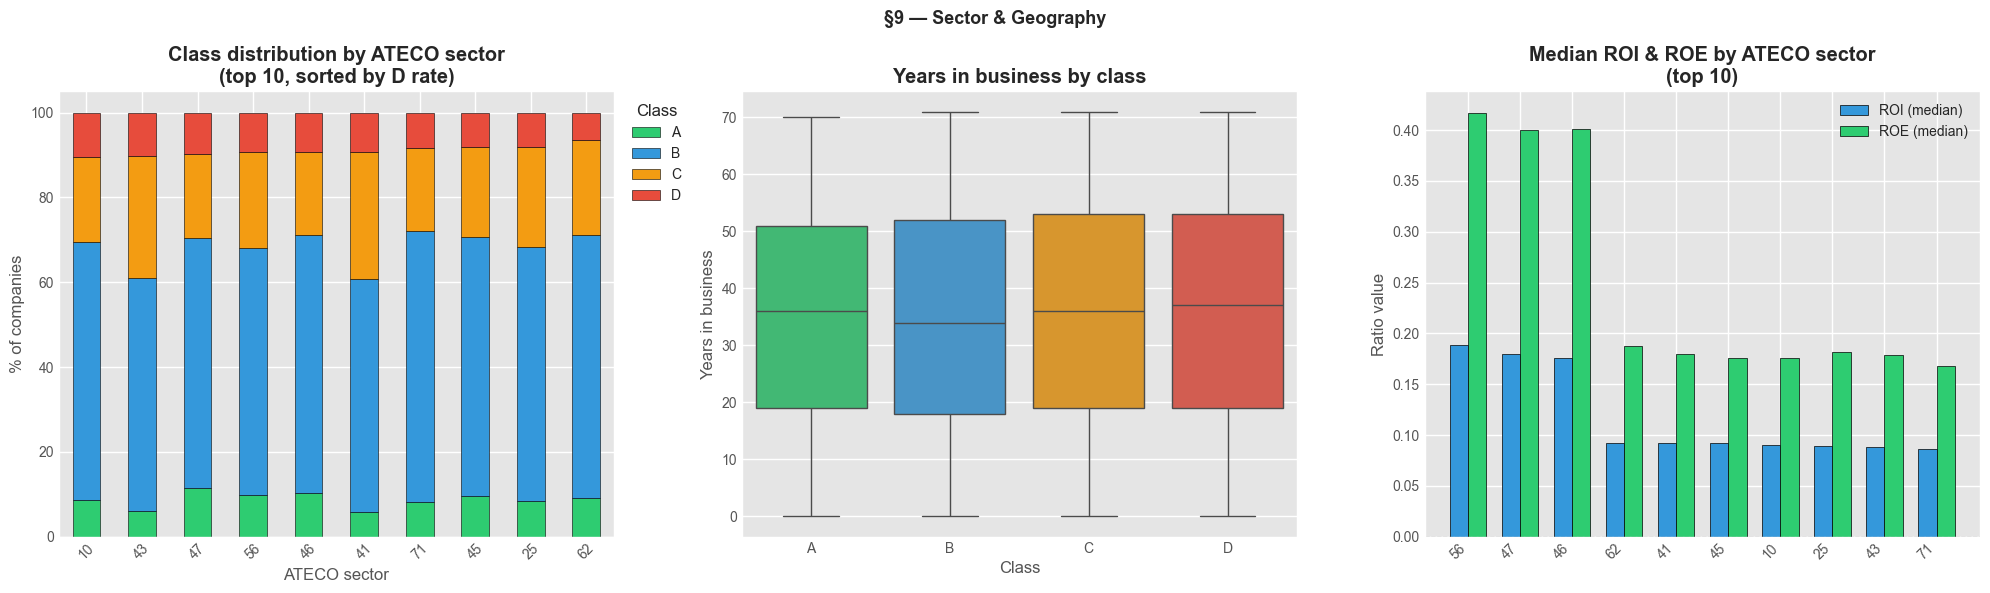

In [137]:
#  plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# left: stacked bar — class distribution by sector
ct_pct_sorted = ct_pct.loc[d_rate.index]  # sort by D rate descending
ct_pct_sorted[CLASS_ORDER].plot(
    kind="bar", stacked=True,
    color=[PALETTE[c] for c in CLASS_ORDER],
    edgecolor="black", linewidth=0.4,
    ax=axes[0],
)
axes[0].set_title("Class distribution by ATECO sector\n(top 10, sorted by D rate)", fontweight="bold")
axes[0].set_xlabel("ATECO sector")
axes[0].set_ylabel("% of companies")
axes[0].legend(title="Class", bbox_to_anchor=(1.01, 1), loc="upper left")
axes[0].tick_params(axis="x", rotation=45)

# middle: years_in_business by class boxplot
sns.boxplot(
    data=df[["financial_health_class", "years_in_business"]].dropna(),
    x="financial_health_class",
    y="years_in_business",
    order=CLASS_ORDER,
    palette=PALETTE,
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
    ax=axes[1],
)
axes[1].set_title("Years in business by class", fontweight="bold")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Years in business")

# right: grouped bar — median ROI & ROE by sector
x = np.arange(len(sector_stats))
w = 0.35
axes[2].bar(x - w/2, sector_stats["roi"], width=w, label="ROI (median)",
            color="#3498db", edgecolor="black", linewidth=0.5)
axes[2].bar(x + w/2, sector_stats["roe"], width=w, label="ROE (median)",
            color="#2ecc71", edgecolor="black", linewidth=0.5)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_xticks(x)
axes[2].set_xticklabels(sector_stats.index, rotation=45, ha="right")
axes[2].set_title("Median ROI & ROE by ATECO sector\n(top 10)", fontweight="bold")
axes[2].set_ylabel("Ratio value")
axes[2].legend()

fig.suptitle("§9 — Sector & Geography", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "eda_s9_sector.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.9 Interpretation

Taken together, the sector and geography diagnostics point to a clear conclusion:

- **Sector is unevenly distributed**, so rare-category handling is necessary.
- **Sector also carries meaningful contextual signal**, because distress rates and profitability profiles vary across industries.
- **Business maturity adds modest supporting information**, but does not appear strong enough to act as a primary standalone driver.
- Geography is useful mainly as broad context, not as a dominant predictive axis.

**Modeling implication**

- Keep `ateco_sector`, but manage sparse categories explicitly.
- Preserve `years_in_business` as a contextual numerical feature.
- Treat sector as especially valuable for **relative benchmarking** (e.g. sector-adjusted ratios), not just raw encoding.

---
## Section 6 — Sector and Geography: Findings

### 6.10 Summary of Contextual Business Structure

The sector and geography analysis shows that contextual descriptors are **not primary predictors**, but they do carry **meaningful supporting structure**.

| Diagnostic | Main Result | Interpretation |
|---|---|---|
| **Sector frequency distribution** | A few sectors dominate while others are sparse | Rare-category handling is necessary |
| **Rare sectors** | Some categories are too small for stable standalone modeling | Grouping or shrinkage-aware encoding is advisable |
| **Class D rate by sector** | Distress concentration differs across industries | Sector carries contextual baseline risk |
| **Median years in business by class** | Maturity varies across classes, but modestly | Useful supporting feature, not a primary driver |
| **Sector median ROI / ROE** | Profitability profiles differ across sectors | Sector is economically meaningful, not just administrative |

---

### 6.11 What This Means for Modeling

The correct treatment is to **retain context without over-weighting it**.

1. **Keep `ateco_sector`**
   - It captures meaningful industry-level structure and distress heterogeneity.

2. **Handle rare sectors explicitly**
   - Group very small categories into `"OTHER"` or use encoders that reduce variance in sparse levels.

3. **Use sector for relative benchmarking**
   - Sector is especially valuable when used to contextualize ratios:
     - sector-relative profitability,
     - sector-relative leverage,
     - or deviations from sector medians.

4. **Keep `years_in_business` as a contextual feature**
   - It adds interpretable lifecycle information, but should not be treated as a dominant predictor.

5. **Treat geography as secondary context**
   - Geographic information may help marginally, but should not be expected to drive strong separation on its own.

---

### 6.12 Final Section Conclusion

Sector and geography should be viewed as **contextual modifiers**, not as substitutes for firm-level financial ratios. Sector, in particular, is worth preserving because it helps explain both **baseline risk differences** and **what “normal” financial behavior looks like within an industry**.

→ The best downstream use of this information is **context-aware feature engineering**, not raw categorical dependence alone.

In [138]:
# 1. Loading and basic cleaning
df = train_df.copy()
TARGET = "financial_health_class"

# Exclude ID, target, and temporal/categorical variables from the numeric test
exclude_cols = [
    "company_id", "fiscal_year", "ateco_sector", "province", "region", "legal_form", 
    "bankruptcy_next_year", "financial_health_class", "revenue_change"
]

# Automatically find all remaining numeric columns
features_base = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

print(f"Analyzing {len(features_base)} numeric features\n")

# Remove only rows without target or ATECO sector (fundamental for the test)
df_clean = df.dropna(subset=["ateco_sector", TARGET]).copy()

# 2. Missing value imputation (only for calculating Mutual Information)
# We use the median to prevent the algorithm from failing
imputer = SimpleImputer(strategy='median')
df_clean[features_base] = imputer.fit_transform(df_clean[features_base])

# 3. Create Delta features (Value - Sector Mean)
features_delta = []
for f in features_base:
    sector_mean = df_clean.groupby("ateco_sector")[f].transform("mean")
    delta_col = f"{f}_delta"
    df_clean[delta_col] = df_clean[f] - sector_mean
    # If a sector has only one company, the mean calculation might result in NaN, fill with 0
    df_clean[delta_col] = df_clean[delta_col].fillna(0) 
    features_delta.append(delta_col)

# 4. Prepare data for calculation
X = df_clean[features_base + features_delta]
y = df_clean[TARGET].astype("category").cat.codes

# 5. Calculate Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)

# 6. Compile and print results
results = []
for i, f in enumerate(features_base):
    score_raw = mi_scores[i]
    score_delta = mi_scores[len(features_base) + i]
    
    # Kept clean and academic
    winner = "Raw" if score_raw >= score_delta else "Delta"
    diff_percent = ((score_delta - score_raw) / score_raw) * 100 if score_raw > 0 else 0
    
    results.append({
        "Feature": f,
        "Raw Score": score_raw,     # Kept as float for accurate sorting
        "Delta Score": score_delta, # Kept as float for accurate sorting
        "Winner": winner,
        "% Change": diff_percent
    })

# Sort the dataframe first based on the raw float values
df_results = pd.DataFrame(results).sort_values(by="Raw Score", ascending=False)

# Clean formatting for 0 and precise alignment
df_results["Raw Score"] = df_results["Raw Score"].apply(lambda x: "0" if round(x, 4) == 0 else f"{x:.4f}")
df_results["Delta Score"] = df_results["Delta Score"].apply(lambda x: "0" if round(x, 4) == 0 else f"{x:.4f}")
df_results["% Change"] = df_results["% Change"].apply(lambda x: f"{x:+.1f}%")

print("MUTUAL INFORMATION RESULTS (Task 2: Financial Health)\n")
print(df_results.to_markdown(
    index=False, 
    colalign=("left", "right", "right", "left", "right")
))

Analyzing 23 numeric features

MUTUAL INFORMATION RESULTS (Task 2: Financial Health)

| Feature              |   Raw Score |   Delta Score | Winner   |   % Change |
|:---------------------|------------:|--------------:|:---------|-----------:|
| debt_to_assets       |      0.7912 |        0.7692 | Raw      |      -2.8% |
| leverage             |      0.7894 |        0.7325 | Raw      |      -7.2% |
| profit_margin        |      0.3292 |        0.3208 | Raw      |      -2.6% |
| op_cost_ratio        |       0.262 |        0.2481 | Raw      |      -5.3% |
| roe                  |       0.245 |        0.1857 | Raw      |     -24.2% |
| roi                  |      0.2401 |        0.1843 | Raw      |     -23.3% |
| net_profit_loss      |      0.2165 |        0.0855 | Raw      |     -60.5% |
| current_ratio        |      0.1937 |        0.2245 | Delta    |     +15.9% |
| quick_ratio          |       0.191 |        0.2255 | Delta    |     +18.1% |
| operating_income     |      0.1305 |       

In [139]:
TARGET = "financial_health_class"
YEAR_COL = "fiscal_year"

# --- Sector mapping ---
ateco_map = {
    (10, 33): "Manufacturing",
    (41, 43): "Construction",
    (45, 47): "Wholesale & Retail",
    (55, 56): "Accommodation & Food",
    (58, 63): "Info & Communication",
    (68, 68): "Real Estate",
    (69, 75): "Prof. & Scientific",
    (77, 82): "Admin & Support",
}

def get_sector_name(code):
    try:
        c = int(code)
        for (lo, hi), name in ateco_map.items():
            if lo <= c <= hi:
                return name
    except:
        pass
    return "Other"

df = train_df.copy()
df["sector_name"] = (
    df["ateco_sector"].astype(str).str.zfill(2).apply(get_sector_name)
)

# --- Build 100% distribution per sector ---
CLASS_ORDER = ["A", "B", "C", "D"]
CLASS_COLORS = {
    "A": "#4CAF50",   # green
    "B": "#2196F3",   # blue
    "C": "#FF9800",   # orange
    "D": "#D32F2F"    # red
}

dist = (
    df.groupby(["sector_name", TARGET])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=CLASS_ORDER, fill_value=0)
)

dist_pct = dist.div(dist.sum(axis=1), axis=0).mul(100)

# ordine settori come nel grafico Canva
sector_order = [
    "Real Estate",
    "Info & Communication",
    "Prof. & Scientific",
    "Manufacturing",
    "Wholesale & Retail",
    "Admin & Support",
    "Accommodation & Food",
    "Construction"
]

dist_pct = dist_pct.reindex([s for s in sector_order if s in dist_pct.index])

global_d = df[TARGET].value_counts(normalize=True).get("D", 0) * 100

# --- Plot ---
fig1 = go.Figure()

for cls in CLASS_ORDER:
    fig1.add_trace(
        go.Bar(
            name=f"Class {cls}",
            x=dist_pct[cls],
            y=dist_pct.index.tolist(),
            orientation="h",
            marker=dict(color=CLASS_COLORS[cls], line=dict(width=0)),
            hovertemplate=f"Class {cls}: %{{x:.1f}}%<extra></extra>"
        )
    )

# baseline D
fig1.add_vline(
    x=global_d,
    line=dict(color="#d32f2f", width=1.5, dash="dot")
)

fig1.add_annotation(
    x=global_d,
    y=-0.7,
    xref="x",
    yref="y",
    text=f"<i>D baseline {global_d:.1f}%</i>",
    showarrow=False,
    font=dict(size=13, color="#d32f2f"),
    xanchor="left"
)

fig1.update_layout(
    title=dict(
        text=(
            "<b>ATECO Sector: Class Distribution</b>"
            "<br><span style='font-size:11px; font-weight:normal; color:#777777;'>"
            "D-rate spread across sectors → weak standalone signal"
            "</span>"
        ),
        x=0.5,
        xanchor="center",
        y=0.95,
        font=dict(size=18, color="#222222")
    ),
    barmode="stack",
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(family="Arial", size=12, color="#333333"),
    width=1050,
    height=520,
    margin=dict(t=90, l=170, r=40, b=80),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.12,
        xanchor="center",
        x=0.5,
        bgcolor="rgba(0,0,0,0)",
        traceorder="normal"
    ),
    xaxis=dict(
        title="Share (%)",
        range=[0, 100],
        dtick=20,
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        title="",
        showgrid=False,
        autorange="reversed"
    )
)

fig1.show()

In [140]:
# --- Constants
TARGET = "financial_health_class"
N_BOOT = 30

# --- Feature -> category map
CAT_MAP = {
    "roe": "PROFITABILITY",
    "roi": "PROFITABILITY",
    "profit_margin": "PROFITABILITY",
    "debt_to_assets": "SOLVENCY",
    "current_ratio": "LIQUIDITY",
    "log_total_assets": "SIZE",
    "years_in_business": "AGE",
}

# --- Display labels exactly as in slide
DISPLAY_NAME_MAP = {
    "current_ratio": "CURRENT_RATIO",
    "years_in_business": "YEARS_IN_BUSINESS",
    "log_total_assets": "LOG_TOTAL_ASSETS",
    "profit_margin": "PROFIT_MARGIN",
    "debt_to_assets": "DEBT_TO_ASSETS",
    "roi": "ROI",
    "roe": "ROE",
}

# --- Native + derived features
NATIVE = [
    "roe", "roi", "debt_to_assets", "profit_margin",
    "current_ratio", "years_in_business"
]

DERIVED = {
    "log_total_assets": lambda df: np.log1p(df["total_assets"]),
}

ALL_FEATURES = NATIVE + list(DERIVED.keys())
RAW_COLS_FOR_DERIVED = ["production_costs", "production_value", "total_assets"]

# --- Load and prep
load_cols = NATIVE + RAW_COLS_FOR_DERIVED + ["sector_name", TARGET]
load_cols = list(dict.fromkeys(load_cols))

df_mi = (
    train_df[load_cols]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
    .reset_index(drop=True)
)

for col, fn in DERIVED.items():
    df_mi[col] = fn(df_mi)

df_mi = df_mi[ALL_FEATURES + ["sector_name", TARGET]].dropna().reset_index(drop=True)

# --- Target encoding
y = df_mi[TARGET].astype("category").cat.codes

# --- Sector medians
sector_medians = df_mi.groupby("sector_name")[ALL_FEATURES].median()

# --- Sector-normalized features
for col in ALL_FEATURES:
    df_mi[f"{col}_vs_sector"] = (
        df_mi[col] - df_mi["sector_name"].map(sector_medians[col])
    )

# --- MI + bootstrap CI
rng = np.random.default_rng(42)
mi_results = []

for col in ALL_FEATURES:
    rel_col = f"{col}_vs_sector"

    mi_raw = mutual_info_classif(df_mi[[col]], y, random_state=42)[0]
    mi_rel = mutual_info_classif(df_mi[[rel_col]], y, random_state=42)[0]
    delta = mi_rel - mi_raw
    pct = (delta / mi_raw * 100) if mi_raw > 0 else 0.0

    boot_deltas = []
    for _ in range(N_BOOT):
        idx = rng.choice(len(df_mi), size=len(df_mi), replace=True)
        y_b = y.iloc[idx].reset_index(drop=True)
        sub = df_mi.iloc[idx].reset_index(drop=True)

        seed = int(rng.integers(0, 1_000_000))
        mi_r_b = mutual_info_classif(sub[[col]], y_b, random_state=seed)[0]
        mi_a_b = mutual_info_classif(sub[[rel_col]], y_b, random_state=seed)[0]
        boot_deltas.append(mi_a_b - mi_r_b)

    ci_low = np.percentile(boot_deltas, 5)
    ci_high = np.percentile(boot_deltas, 95)

    mi_results.append({
        "col": col,
        "display_name": DISPLAY_NAME_MAP.get(col, col.upper()),
        "category": CAT_MAP.get(col, "OTHER"),
        "mi_raw": mi_raw,
        "delta": delta,
        "pct": pct,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "ci_crosses_zero": ci_low < 0 < ci_high
    })

# Same visual ordering as slide
mi_results.sort(key=lambda x: x["delta"], reverse=True)

# --- y positions (numeric, so we can fully control labels)
n = len(mi_results)
y_pos = list(range(n))

deltas = [d["delta"] for d in mi_results]
pcts = [d["pct"] for d in mi_results]

# --- Colors
def get_bar_color(v):
    if v >= 0:
        return "#A8C5AE"   # soft green
    elif v >= -0.015:
        return "#F2B8B1"   # light salmon
    elif v >= -0.040:
        return "#C93A2B"   # medium red
    else:
        return "#8E261A"   # dark red

bar_colors = [get_bar_color(d["delta"]) for d in mi_results]
bar_opacities = [0.45 if d["ci_crosses_zero"] else 1.0 for d in mi_results]

# --- Error bars
err_plus = [abs(d["ci_high"] - d["delta"]) for d in mi_results]
err_minus = [abs(d["delta"] - d["ci_low"]) for d in mi_results]

# --- X range
x_min = min([d["ci_low"] for d in mi_results] + deltas)
x_max = max([d["ci_high"] for d in mi_results] + deltas)
span = x_max - x_min

x_min_plot = min(-0.10, x_min - span * 0.20)
x_max_plot = max(0.07, x_max + span * 0.22)

fig = go.Figure()

# Main bars
fig.add_trace(
    go.Bar(
        x=deltas,
        y=y_pos,
        orientation="h",
        marker=dict(
            color=bar_colors,
            opacity=bar_opacities,
            line=dict(width=0)
        ),
        error_x=dict(
            type="data",
            symmetric=False,
            array=err_plus,
            arrayminus=err_minus,
            color="#BDBDBD",
            thickness=1.4,
            width=3
        ),
        hovertemplate="<b>%{customdata}</b><br>ΔMI = %{x:.4f}<extra></extra>",
        customdata=[d["display_name"] for d in mi_results],
        cliponaxis=False
    )
)

# Zero line
fig.add_vline(x=0, line=dict(color="#7F8C8D", width=2))
fig.add_vline(
    x=x_min_plot + 0.001,
    line=dict(color="#C7C7C7", width=2)
)

# --- Left-side custom labels (2 lines, first bold)
for yi, d in zip(y_pos, mi_results):
    fig.add_annotation(
        x=x_min_plot + 0.002,
        y=yi,
        xref="x",
        yref="y",
        text=(
            f"<b>{d['display_name']}</b>"
            f"<br><span style='font-size:9px; color:#6E6E6E;'>{d['category']}</span>"
        ),
        showarrow=False,
        xanchor="right",
        align="right",
        xshift=-12,
        font=dict(size=10, color="#2B2B2B", family="Arial")
    )

# --- External value labels
label_x_map = {
    "current_ratio": 0.022,
    "years_in_business": 0.015,
    "log_total_assets": -0.026,
    "profit_margin": -0.030,
    "debt_to_assets": -0.045,
    "roi": -0.066,
    "roe": -0.078,
}

for yi, d in zip(y_pos, mi_results):
    if d["delta"] >= 0:
        x_txt = label_x_map.get(d["col"], d["ci_high"] + 0.002)
        xanchor = "left"
        color = "#2E8B57"
    else:
        x_txt = label_x_map.get(d["col"], d["delta"] - 0.010)
        xanchor = "right"
        color = "#C93A2B"

    fig.add_annotation(
        x=x_txt,
        y=yi,
        xref="x",
        yref="y",
        text=f"<b>{d['delta']:+.4f} ({d['pct']:+.1f}%)</b>",
        showarrow=False,
        xanchor=xanchor,
        yanchor="middle",
        font=dict(size=11, color=color, family="Arial")
    )

fig.add_annotation(
    x=0.04,
    y=1.08,
    xref="x",
    yref="paper",
    text="<b>NORMALIZATION HELPS →</b><br><span style='font-size:9px'>(Sector-adjusted is better)</span>",
    showarrow=False,
    font=dict(size=10, color="#2E8B57", family="Arial"),
    align="center"
)

# Layout
fig.update_layout(
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(family="Arial", size=11, color="#222222"),
    width=1120,
    height=560,
    bargap=0.34,
    showlegend=False,
    margin=dict(t=120, l=220, r=75, b=70),
    title=dict(
        text=(
            "<b>Does Sector Normalization Improve Predictive Power?</b>"
            "<br><span style='font-size:11px; color:#7A7A7A;'>"
            "ΔMI = Information Gain (ΔMI) · Whiskers: 90% Bootstrap Confidence Interval"
            "</span>"
        ),
        x=0.5,
        xanchor="center",
        y=0.965,
        font=dict(size=19, color="#222222", family="Arial")
    ),
    xaxis=dict(
        title="<b>ΔMI (Information Gain Shift)</b>",
        range=[x_min_plot, x_max_plot],
        showgrid=True,
        gridcolor="#E8E8E8",
        gridwidth=1,
        zeroline=False,
        tickfont=dict(size=10),
        title_font=dict(size=12)
    ),
    yaxis=dict(
        range=[-0.5, n - 0.5],
        showgrid=False,
        showticklabels=False,   # hides default labels
        zeroline=False,
        autorange="reversed"
    )
)

fig.show()

In [141]:
# Contingency table:
#                   Class D    Not D
# is_last_obs = 1     k         67-k       (uscite)
# is_last_obs = 0     m         n-m        (resto del dataset)

n_total    = len(train_df)
n_exits    = 67
n_d_total  = (train_df["financial_health_class"] == "D").sum()

# Dalle tue statistiche: 65% delle uscite sono D
k = round(0.65 * n_exits)          # ~44 exit rows che sono D

contingency = np.array([
    [k,            n_exits - k],              # uscite
    [n_d_total - k, n_total - n_exits - (n_d_total - k)]  # resto
])

odds_ratio, p_value = fisher_exact(contingency, alternative="greater")

print(f"Odds Ratio: {odds_ratio:.1f}x")
print(f"p-value:    {p_value:.2e}")
# Atteso: OR >> 1, p << 0.001


Odds Ratio: 20.3x
p-value:    2.27e-30


In [142]:
TARGET = "financial_health_class"

# ── 1. Calcolo della matrice di transizione ───────────────────────────────────
df_sorted = (
    train_df[["company_id", "fiscal_year", TARGET]]
    .sort_values(["company_id", "fiscal_year"])
    .copy()
)

# class_next: classe dell'anno successivo per la stessa azienda
df_sorted["class_next"] = (
    df_sorted.groupby("company_id")[TARGET].shift(-1)
)

# Ultima osservazione di ogni azienda nel training set
last_year_per_company = df_sorted.groupby("company_id")["fiscal_year"].transform("max")

# Distingui due tipi di NaN in class_next:
#   EXIT      → azienda che sparisce PRIMA dell'ultimo anno del training (2021)
#               NaN perché non ha più righe nel dataset, non perché è fine panel
#   TRAIN_END → ultima osservazione del training set (2021), il 2022 è nel test
#               NON è un'uscita genuina — escludila dal calcolo
df_sorted["class_next"] = df_sorted["class_next"].where(
    df_sorted["class_next"].notna(),                 # se non NaN → mantieni
    other=np.where(
        last_year_per_company < df_sorted["fiscal_year"].max(),
        "EXIT",        # NaN + ultima anno < 2021 → uscita genuina
        "TRAIN_END"    # NaN + ultima anno == 2021 → fine training, non exit
    )
)

# Rimuovi le righe TRAIN_END prima di calcolare le transizioni
df_trans = df_sorted[df_sorted["class_next"] != "TRAIN_END"].copy()

# Matrice di transizione raw (conteggi)
trans_counts = (
    df_trans
    .groupby([TARGET, "class_next"])
    .size()
    .unstack(fill_value=0)
)

# Ordine colonne canonico
col_order = [c for c in ["A", "B", "C", "D", "EXIT"] if c in trans_counts.columns]
row_order = [c for c in ["A", "B", "C", "D"] if c in trans_counts.index]
trans_counts = trans_counts.reindex(index=row_order, columns=col_order, fill_value=0)

# Normalizza per riga → probabilità di transizione (%)
trans_pct = trans_counts.div(trans_counts.sum(axis=1), axis=0) * 100

# Verifica rigore: stampa somme di riga e conteggi
print("=== Conteggi per riga ===")
print(trans_counts)
print("\n=== Probabilità di transizione (%) ===")
print(trans_pct.round(1).to_string())
print("\n=== Somme di riga (devono essere ~100) ===")
print(trans_pct.sum(axis=1).round(2))
print(f"\nRighe usate: {len(df_trans)} | Escluse TRAIN_END: {(df_sorted['class_next']=='TRAIN_END').sum()}")

# ── 2. Costruzione colori per cella ──────────────────────────────────────────
rank = {"A": 0, "B": 1, "C": 2, "D": 3, "EXIT": 4}

classes_from = trans_pct.index.tolist()
classes_to   = trans_pct.columns.tolist()
matrix       = trans_pct.values

cell_colors      = []
cell_font_colors = []

for r, cf in enumerate(classes_from):
    row_colors = []
    row_fonts  = []
    for c, ct in enumerate(classes_to):
        val = matrix[r, c]
        fr  = rank[cf]
        tr  = rank[ct]

        if ct == "EXIT":
            intensity = min(val / 10.0, 1.0)
            row_colors.append(f"rgba(192,57,43,{0.4 + 0.6*intensity:.2f})")
            row_fonts.append("white" if val > 0 else "#95A5A6")

        elif fr == tr:
            intensity = min(val / 70.0, 1.0)
            row_colors.append(f"rgba(52,73,94,{0.15 + 0.55*intensity:.2f})")
            row_fonts.append("white" if val > 30 else "#2C3E50")

        elif tr > fr:
            # peggioramento
            jump = tr - fr
            intensity = min((val / 30.0) * (jump / 3.0), 1.0)
            row_colors.append(f"rgba(192,57,43,{0.12 + 0.65*intensity:.2f})")
            row_fonts.append("white" if intensity > 0.5 else "#2C3E50")

        else:
            # miglioramento
            jump = fr - tr
            intensity = min((val / 65.0) * (jump / 3.0), 1.0)
            row_colors.append(f"rgba(26,122,74,{0.12 + 0.65*intensity:.2f})")
            row_fonts.append("white" if intensity > 0.5 else "#2C3E50")

    cell_colors.append(row_colors)
    cell_font_colors.append(row_fonts)

# ── 3. Formattazione testi cella ─────────────────────────────────────────────
cell_texts = []
for r, cf in enumerate(classes_from):
    row_texts = []
    for c, ct in enumerate(classes_to):
        val = matrix[r, c]
        if val == 0.0:
            row_texts.append("<b>—</b>")
        elif ct == "EXIT":
            row_texts.append(f"<b>{val:.1f}%</b>")
        else:
            row_texts.append(f"{val:.1f}%")
    cell_texts.append(row_texts)

# ── 4. go.Table: trasponi da righe a colonne (Plotly vuole colonne) ───────────
row_headers = [f"<b>From {c}</b>" for c in classes_from]
col_headers = (
    ["<b>Year t</b>"]
    + [f"<b>→ {ct}</b>" if ct != "EXIT" else "<b>→ EXIT ⚠️</b>" for ct in classes_to]
)

# Valori: prima colonna = row headers, poi una colonna per ogni class_to
col_vals        = [[rh for rh in row_headers]]
col_fills       = [["#2C3E50"] * len(classes_from)]
col_font_colors = [["white"] * len(classes_from)]

for c, ct in enumerate(classes_to):
    col_vals.append([cell_texts[r][c] for r in range(len(classes_from))])
    col_fills.append([cell_colors[r][c] for r in range(len(classes_from))])
    col_font_colors.append([cell_font_colors[r][c] for r in range(len(classes_from))])

header_fill_colors = (
    ["#2C3E50"] * (len(classes_to))
    + (["#7B241C"] if "EXIT" in classes_to else [])
)
# header EXIT in rosso scuro
header_fill_colors = ["#2C3E50"] * (1 + len(classes_to))
if "EXIT" in classes_to:
    header_fill_colors[-1] = "#7B241C"

fig = go.Figure(data=[go.Table(
    columnwidth=[90] + [70] * (len(classes_to) - 1) + [90],
    header=dict(
        values=col_headers,
        fill_color=header_fill_colors,
        font=dict(color="white", size=12, family="Inter, Helvetica Neue, Arial"),
        align="center", height=36,
        line_color="#1a252f",
    ),
    cells=dict(
        values=col_vals,
        fill_color=col_fills,
        font=dict(color=col_font_colors, size=12.5,
                  family="Inter, Helvetica Neue, Arial"),
        align="center", height=38,
        line_color="rgba(255,255,255,0.25)",
    ),
)])

# Subtitle dinamico con n osservazioni e n exit genuini
n_trans  = len(df_trans)
n_exits  = int((df_trans["class_next"] == "EXIT").sum())

fig.update_layout(
    paper_bgcolor="white",
    font=dict(family="Inter, Helvetica Neue, Arial"),
    title=dict(
        text=(
            "Year-to-Year Class Transition Probabilities<br>"
            f"<span style='font-size:11px;color:#95A5A6;font-weight:normal'>"
            f"P(class_{{t+1}} | class_t) · n={n_trans:,} transitions · "
            f"{n_exits} genuine exits (pre-2021) · TRAIN_END rows excluded · rows sum to 100%"
            "</span>"
        ),
        font=dict(size=13, color="#2C3E50"),
        x=0.5, xanchor="center",
    ),
    margin=dict(t=80, l=10, r=10, b=10),
    height=310,
    width=620,
)

fig.show()
# fig.write_image("transition_matrix.png", scale=2)


=== Conteggi per riga ===
class_next                A     B     C    D  EXIT
financial_health_class                            
A                        83   456   157   57     0
B                       437  3109  1309  471     0
C                       167  1180   490  189     0
D                        60   430   146   88    67

=== Probabilità di transizione (%) ===
class_next                 A     B     C     D  EXIT
financial_health_class                              
A                       11.0  60.6  20.8   7.6   0.0
B                        8.2  58.4  24.6   8.8   0.0
C                        8.2  58.2  24.2   9.3   0.0
D                        7.6  54.4  18.5  11.1   8.5

=== Somme di riga (devono essere ~100) ===
financial_health_class
A    100.0
B    100.0
C    100.0
D    100.0
dtype: float64

Righe usate: 8896 | Escluse TRAIN_END: 2932
